<a href="https://colab.research.google.com/github/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/blob/main/tropicalcyclone_rapidintensification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tropical Cyclone Rapid Intensification (RI) Prediction using Machine Learning

---
**Author(s)**:
Author, Affiliation, Email

> This tutorial is a beginner-friendly walkthrough of predicting Rapid Intensification (RI) in tropical cyclones- the sudden, dangerous jump (>30 knots over 24 hours) in wind speed that makes cyclones so hard to forecast. Using real best-track records, satellite imagery, and atmospheric/oceanic reanalysis data, you'll learn how to frame RI as a rare-event classification problem, train and evaluate a model with metrics suited to imbalanced, safety-critical forecasting, and see how such models could potentially give forecasters more lead time to issue evacuation warnings before a storm suddenly strengthens.

---

# Table of Contents

*   [Overview](#overview)
*   [Climate Impact](#climate-impact)
*   [Target Audience](#target-audience)
*   [Software Requirements](#software-requirements)
*   [Background & Prerequisites](#background)
*   [Data Description](#data-description)
*   [Methodology](#methodology)
*   [Results & Discussion](#results-and-discussion)
*   [References](#references)

---
<a name="overview"></a>
# Overview

In September 2024, Hurricane Helene's winds climbed from 40 kt (45 mph) to 70 kt (80 mph) in a single day, and it came ashore at 120 kt (140 mph) barely a day and a half later. This is know as **Rapid Intensification (RI)**: a sudden, dramatic jump in a cyclone's strength, and one of the hardest problems in operational meteorology to forecast.

This tutorial's goal is to show how Machine Learning can be applied to RI: given a cyclone's state at time *t*, can we predict whether it will intensify by more than 30 knots by *t+24h*? To get there, we'll assemble a multi-modal dataset from best-track records, ERA5 reanalysis fields, and satellite imagery, then train and evaluate a model with an honest eye on both what it gets right and where it falls short.

By the end of the tutorial, you will be able to:
1.  Explain what RI is and why it is difficult to forecast.
2.  Derive and understand explanable features from multi-modal dataset containing best-track records (IBTrACS), ERA5 reanalysis, and satellite imagery (GridSat).
3.  Visualize and explore the properties and behavior of tropical cyclones.
4.  Recognize why class imbalance makes standard metrics like accuracy misleading for rare-event problems.
5.  Choose and interpret evaluation metrics suited to rare, high-stakes prediction problems: precision-recall curves, probability of detection, false alarm ratio, and Brier skill score.
6.  Critically assess an ML model's real-world limitations.

Let's get started!

---
<a name="climate-impact"></a>
# Climate Impact

## The problem

Tropical cyclone forecasters have got much better at predicting *where* a storm will go, but predicting *how strong it will get* remains one of the hardest problems in operational meteorology. Predicting rapid intensification remains challenging because it involves complex, interacting processes within the storm and its surrounding environment. Weather models can struggle to capture the small-scale processes near the storm's core, while observations of these processes are often limited.

## RI in a Changing Climate

Rapid intensification is not only a forecasting challenge; it is also relevant to a changing climate. Research suggests that warming oceans and other climate-driven changes are affecting how tropical cyclones intensify:

* **Globally**, studies have found an increase in tropical cyclone intensification rates, with human-caused warming contributing to conditions that can support stronger intensification (Bhatia et al., 2022).
* **Near coastlines**, where rapidly intensifying storms pose a greater risk, the number of RI events occurring within 400 km of the coast has increased substantially since 1980, with ocean warming identified as an important factor (Nature Communications, 2023).
* The **IPCC Sixth Assessment Report** identifies increases in the likelihood of RI in the Atlantic, Northwest Pacific, and globally as a likely detectable signal of human-caused climate change.

## Why Better RI Prediction Matters

RI can rapidly turn a dangerous storm into a catastrophic one, leaving communities less time to prepare.

* **Better decisions:** More accurate intensity forecasts help officials plan evacuations and emergency response.
* **Fewer losses:** Improved hurricane forecasts can reduce deaths and economic damage.
* **Earlier warnings:** Events like Hurricane Otis show how sudden intensification can catch communities off guard.


## Who uses this, and how

* **Meteorological agencies:** Use RI predictions to improve hurricane intensity forecasts and warnings.
* **Emergency managers:** Use forecasts to plan evacuations, shelters, and resources.
* **Coastal communities:** Get earlier and more accurate warnings to make evacuation decisions.
* **Insurers & disaster-response groups:** Use intensity forecasts to assess risk and prepare resources.


## Where this tutorial fits

The tool built in this tutorial **does not replace** operational systems like NOAA's SHIPS-RII or HAFS. Those run on real-time forecast fields, not the reanalysis data (ERA5) we use here.

What this tutorial offers instead is a hands-on, accessible entry point into the *same underlying problem* those operational systems solve: given a cyclone's current state, will it intensify rapidly?

Our focus will be on building deep understanding of how the predictors of rapid intensification (features) are calculated in real systems and why they make sense. Interpretability of features and how they impact the relevant metrics will be emphasized over getting the best metrics.

---
<a name="target-audience"></a>
# Target Audience

This tutorial is designed for:
*   Beginner-to-intermediate ML practitioners and students with basic Python knowledge, looking for a hands-on example of applying ML to a real-world, climate-relevant forecasting problem. No prior meteorology background is required, but would be helpful.
*   Climate scientists and researchers interested in exploring how ML can be applied to a domain-specific forecasting problem they already understand.
*   Anyone working, or hoping to work at the intersection of ML and climate science.

---
<a name="software-requirements"></a>
# Software Requirements

This notebook was developed in August 2026, and requires **Python 3.13.15** . The following key libraries are required:

* fsspec==2025.3.0
* gcsfs==2025.3.0
* matplotlib==3.11.1
* numpy==2.1.3
* pandas==2.2.3
* scikit-learn==1.9.0
* xarray==2026.7.0
* xgboost==3.4.1
* zarr==3.3.0

A complete list of all dependencies and exact versions is provided in the accompanying `requirements.txt` file.

To set up a local environment:
```bash
pip install -r requirements.txt
```

Inside Google Colab:
```bash
!pip install -q -r https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/refs/heads/main/requirements.txt
```


In [1]:
!pip install -q -r https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/refs/heads/main/requirements.txt

## Library Imports

In [2]:
# Standard library
import os
import time
import urllib.request
import warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from functools import lru_cache
from pathlib import Path

# Data
import fsspec
import numpy as np
import pandas as pd
import requests
import xarray as xr
from pandas.api.types import is_datetime64_any_dtype

# Plotting
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# Image / Display
from IPython.display import Markdown, display, Image as ShowGIF
from PIL import Image

# Widgets
import ipywidgets as widgets

# ML
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

Run the following command to install required dependencies in Google Colab:

In [3]:
# ---------------------------------------------------------
# Environment setup
# ---------------------------------------------------------
os.environ.setdefault("GRPC_VERBOSITY", "ERROR")
os.environ.setdefault("GLOG_minloglevel", "2")

warnings.simplefilter(action="ignore", category=pd.errors.PerformanceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("future.no_silent_downcasting", True)

pio.renderers.default = "notebook_connected"

In [4]:
# @title Constants used in the code

# ---------------------------------------------------------
# Source data
# ---------------------------------------------------------

IBTRACS_AFTER_1980_CSV_URL = (
    "https://www.ncei.noaa.gov/data/"
    "international-best-track-archive-for-climate-stewardship-ibtracs/"
    "v04r01/access/csv/ibtracs.since1980.list.v04r01.csv"
)

# ---------------------------------------------------------
# GitHub release
# ---------------------------------------------------------

GITHUB_RELEASE_API_URL = (
    "https://api.github.com/repos/"
    "ccai-tropicalcycloneri-tutorial-2026/"
    "tropicalcycloneriprediction/releases/tags/dataset_v4"
)

release = requests.get(GITHUB_RELEASE_API_URL).json()

ASSET_URLS = {
    asset["name"]: asset["browser_download_url"]
    for asset in release["assets"]
}

ERA5_FEATURES_URL = ASSET_URLS["era5_features.parquet"]
SATELLITE_FEATURES_URL = ASSET_URLS["satellite_features.parquet"]

ERA5_FEATURES_FILE = "era5_features.parquet"
SATELLITE_FEATURES_FILE = "satellite_features.parquet"

# ERA5 data store
STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"

# ---------------------------------------------------------
# Spatial calculation
# ---------------------------------------------------------

EARTH_R_KM = 6371.0088
KM_PER_DEG = EARTH_R_KM * np.pi / 180.0
R_DISC = 200.0

# ---------------------------------------------------------
# Storm categories
# ---------------------------------------------------------

STORM_CATEGORIES = [
    (0, "Tropical Depression"),
    (34, "Tropical Storm"),
    (64, "Category 1"),
    (83, "Category 2"),
    (96, "Category 3"),
    (113, "Category 4"),
    (137, "Category 5"),
]

# ---------------------------------------------------------
# Basin information
# ---------------------------------------------------------

BASIN_NAMES = {
    "NA": "North Atlantic",
    "EP": "Eastern North Pacific",
    "WP": "Western North Pacific",
    "NI": "North Indian",
    "SI": "South Indian",
    "SP": "Southern Pacific",
    "SA": "South Atlantic",
}

# ---------------------------------------------------------
# Data columns
# ---------------------------------------------------------

NUMERIC_IBTRACS_COLUMNS = [
    "season",
    "lat",
    "lon",
    "usa_wind",
    "dist2land",
    "storm_speed",
]

# ---------------------------------------------------------
# RI definition
# ---------------------------------------------------------

RI_THRESHOLD_KT = 30
RI_HOURS_IN_FUTURE = 24

# ---------------------------------------------------------
# Train / validation / test split
# ---------------------------------------------------------

TRAIN_END = 2010
VAL_END = 2015
TEST_END = 2025

# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42
np.random.seed(SEED)

# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

STORM_CATEGORY_COLORS = {
    "Tropical Depression": "#6EC1EA",
    "Tropical Storm": "#4DFFFF",
    "Category 1": "#FFFFD9",
    "Category 2": "#FFD98C",
    "Category 3": "#FF9E59",
    "Category 4": "#FF738A",
    "Category 5": "#A188FC",
}

BASIN_COLORS = {
    "NA": "#C85A5A",
    "EP": "#5B82B0",
    "WP": "#D18A45",
    "NI": "#8066A6",
    "SI": "#6FA35F",
    "SP": "#9A684F",
    "SA": "#B85F8A",
}


---
<a name="background"></a>
# Background and Prerequisites

**Estimated time:** ~2 hours  
To follow this tutorial, you should be comfortable with:
*   **Basic Python**: Variables, functions, loops, and using libraries such as `pandas` and `numpy`.
*   **Basic ML concepts**: What a train/validation/test split is and what is binary classification. What are the ML evaluation techniques, especially for imbalanced data? Some familiarity with `scikit-learn`.
*   **Running notebooks**: This tutorial runs in Google Colab, so no local setup is required. Some familiarity with Jupyter notebooks, such as running cells in order, will be helpful.

**No prior knowledge of meteorology, oceanography, or climate science is required.** The scientific concepts you need are explained below and introduced again when they appear in the tutorial. Also, advanced readings and links will be provided for interested folks.

**Run in:** Google Colab (recommended) or any Jupyter environment  

---
### Let us learn about tropical cyclones and rapid intensification (RI)

A short primer on what tropical cyclones are, how they work, and why sudden strengthening is so hard to forecast.


### 1. What is a tropical cyclone?

> A tropical cyclone is a **warm-core low pressure system**, with no attached front, that develops over **tropical or subtropical waters** and has an organized circulation.

The same type of storm goes by different names depending on where it forms:

| Name | Region |
|:--|:--|
| **Hurricane** | North Atlantic, Eastern & Central North Pacific |
| **Typhoon** | Western North Pacific |
| **Cyclone** | North Indian Ocean, South Pacific / Indian Ocean |
| **Severe Tropical Cyclone** | Australia and parts of the South Pacific |

*Different names, same weather system.*

---

### 2. Key characteristics

* **Warm core**  
  - The center is **warmer than the surrounding atmosphere**. The storm draws its energy from warm, moist ocean air rising and releasing **latent heat** as water vapor condenses.

* **Low-pressure center**  
  - A **well-defined center of low pressure** pulls air inward, sustaining the storm's circulation and convection.

* **Cyclonic rotation**  
  - The **Coriolis effect** turns the winds **counterclockwise in the Northern Hemisphere** and **clockwise in the Southern Hemisphere**.

---
### 3. Saffir–Simpson scale
* **What is the Saffir–Simpson Hurricane Wind Scale?**
  - The **Saffir–Simpson Hurricane Wind Scale (SSHWS)** is a **1–5 rating system** used to classify hurricanes based on their **maximum sustained wind speed**.
  - **Categories:**
    - **Category 1:** 64–82 kt (74–95 mph)
    - **Category 2:** 83–95 kt (96–110 mph)
    - **Category 3:** 96–112 kt (111–129 mph)
    - **Category 4:** 113–136 kt (130–156 mph)
    - **Category 5:** ≥137 kt (≥157 mph)

---
### 4. Rapid Intensification (RI)

> **Definition:** RI is the rapid strengthening of a tropical cyclone over a short period, commonly set at an increase of **at least 30 knots in maximum sustained wind within 24 hours**.

* **Why it matters**  
  - A storm can become **far stronger in very little time**, leaving a much smaller window for accurate forecasts and preparation especially near landfall.

* **What causes it**  
  - RI emerges when **favorable environmental conditions** and the cyclone's **internal processes** align: warm ocean water, high atmospheric moisture, weak vertical wind shear, and favorable upper-level outflow.

* **Why it's hard to predict**  
  - It comes out of complex interactions between the **ocean, atmosphere, and the cyclone's inner core** that shift quickly, making RI one of the toughest parts of intensity forecasting.

* **Example**

  - Max sustained wind: **70 kt → 110 kt in 24 hours**  
  - Change: **+40 kt** ≥ 30 kt threshold → ✅ **Rapid intensification**

---
### 🔄 Try it yourself: Wind speed converter and storm category finder

RI is defined as a **30-knot increase in maximum sustained wind over 24 hours**. Run the cell below, and enter different wind speeds in **knots** value below to see the equivalent **mph, km/h, and m/s**, along with the corresponding storm category.

In [5]:
# @title Wind Speed Explorer: knots, mph, km/h, m/s, and storm category
import ipywidgets as widgets
RECORD_KT = 185  # Hurricane Patricia, 2015

def category_for(knots):
    return next(label for threshold, label in reversed(STORM_CATEGORIES) if knots >= threshold)

def legend_html(current):
    return "".join(
        f'<div style="font-weight:{"bold" if label == current else "normal"};">'
        f'{"→ " if label == current else "&nbsp;&nbsp;&nbsp;"}'
        f'<span style="display:inline-block;width:14px;height:14px;background:{STORM_CATEGORY_COLORS[label]};'
        f'border:{"2px solid #000" if label == current else "1px solid #999"};'
        f'vertical-align:middle;margin-right:6px;"></span>{label}</div>'
        for _, label in STORM_CATEGORIES
    )

value_input = widgets.FloatText(value=30.0, description="Wind (kt):")
result = widgets.HTML()

def convert(_=None):
    kt = value_input.value
    mph, kmh, ms = kt * 1.15078, kt * 1.852, kt * 0.514444
    category = category_for(kt)
    ri_note = "meets" if kt >= 30 else "does not meet"
    record_note = f"<br><i>Exceeds the ~{RECORD_KT} kt maximum sustained wind recorded for Hurricane Patricia (2015).</i>" if kt > RECORD_KT else ""

    result.value = f"""
    <div style="font-family:monospace;line-height:1.6;">
    <b>{kt:.1f} kt</b> = {mph:.1f} mph = {kmh:.1f} km/h = {ms:.1f} m/s
    <br><br>As a <b>current wind speed</b>: {category}{record_note}
    <br><br><b>Storm Categories</b> (<a href="https://en.wikipedia.org/wiki/Saffir%E2%80%93Simpson_scale" target="_blank" style="text-decoration:underline;">Saffir–Simpson scale</a>; current speed marked): {legend_html(category)}
    <br>As a <b>24-hour wind-speed increase</b>: {ri_note} the 30 kt <b>Rapid Intensification</b> threshold.
    </div>
    """

value_input.observe(convert, names="value")
convert()
display(widgets.VBox([value_input, result]))

---
## Relevant Videos

The following videos provide additional background on climate change, tropical cyclones, and related forecasting concepts.

This is how climate change impacts tropical cyclones | UNDRR [VIDEO]

<a href="https://www.youtube.com/watch?v=LFzIK7GwS3c">
  <img src="https://img.youtube.com/vi/LFzIK7GwS3c/maxresdefault.jpg" width="300" alt="Watch the tutorial video">
</a>

<br>

How Do Hurricanes Form? | NOAA SciJinks [VIDEO]

<a href="https://www.youtube.com/watch?v=wPDoIrGUrEc">
  <img src="https://img.youtube.com/vi/wPDoIrGUrEc/maxresdefault.jpg" width="300" alt="Watch tutorial video">
</a>

<br>


Intense String of Hurricanes Seen From Space | NASA Goddard [VIDEO]

<a href="https://www.youtube.com/watch?v=xZ0Q-1u40lA">
  <img src="https://img.youtube.com/vi/xZ0Q-1u40lA/maxresdefault.jpg" width="300" alt="Watch tutorial video">
</a>

Yes. I’d make the section a little more polished and consistent, and move the SHIPS note into the introductory paragraph rather than making it feel like an afterthought.

---

<a name="data-description"></a>

# Data Description and Preprocessing

This tutorial combines three complementary data sources to predict rapid intensification (RI):

* **IBTrACS v04r01** provides the storm track and intensity history
* **ERA5** provides the large-scale atmospheric and oceanic environment around the storm
* **GridSat-B1** provides satellite observations of storm cloud structure

> ### ℹ️ Note
>
> Feature selection for the ML model in this tutorial was inspired by predictors commonly used in the **Statistical Hurricane Intensity Prediction Scheme (SHIPS)**, including storm intensity, recent intensity change, motion, and environmental conditions.

### **IBTrACS**

* Global tropical cyclone **best-track data** from 1980 onward, with observations at approximately **6-hourly intervals**.
* Storm location and **USA_WIND** are used to construct the RI label: a **≥30 kt increase in maximum sustained wind over the next 24 hours**.
* [IBTrACS v04r01 data](https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/)
* [IBTrACS v04r01 column documentation](https://www.ncei.noaa.gov/sites/default/files/2025-09/IBTrACS_v04r01_column_documentation.pdf)

### **ERA5**

* Global **gridded reanalysis** at 0.25° × 0.25° spatial resolution and **hourly** temporal resolution.
* Environmental variables such as **sea-surface temperature, moisture, and vertical wind shear** are matched to each storm observation.
* [ERA5 documentation](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels)

### **GridSat-B1**

* Global **geostationary satellite imagery** providing infrared (IR) brightness temperature observations.
* IR imagery is used to characterize **cloud structure** around each storm, including the **cold-cloud fraction (CCF)**.
* [GridSat-B1 documentation](https://www.ncei.noaa.gov/products/gridded-geostationary-brightness-temperature)

We will go through the **download, preprocessing, and exploration** of each dataset before merging them into a single modeling dataset.


---
## 1. IBTrACS (International Best Track Archive for Climate Stewardship)

> IBTrACS (International Best Track Archive for Climate Stewardship) is NOAA's global archive of tropical cyclone best-track data. Best-track data provide post-storm estimates of a cyclone's location and intensity throughout its lifetime, typically at 6-hour intervals. IBTrACS consolidates best-track records from multiple meteorological agencies into a standardized global dataset, including storm position, maximum sustained wind, and other characteristics.

> IBTrACS v04r01, all basins, 1980 onward, straight from NOAA NCEI. Row 1 of the CSV is a units row, not data, hence `skiprows=[1]`. `keep_default_na=False` keeps the basin code `"NA"` (North Atlantic) from being read as NaN.

### 1.1 Data Download
DataFrame (df) = Pandas table of rows and columns

In [6]:
df_ibtracs = pd.read_csv(
    IBTRACS_AFTER_1980_CSV_URL,
    delimiter=",",
    header=0,
    skiprows=[1],
    keep_default_na=False,
    low_memory=False,
)

print(f"raw ibtracs shape: {df_ibtracs.shape}")
df_ibtracs.head()

raw ibtracs shape: (308695, 174)


,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES,WMO_AGENCY,TRACK_TYPE,DIST2LAND,LANDFALL,IFLAG,USA_AGENCY,USA_ATCF_ID,USA_LAT,USA_LON,USA_RECORD,USA_STATUS,USA_WIND,USA_PRES,USA_SSHS,USA_R34_NE,USA_R34_SE,USA_R34_SW,USA_R34_NW,USA_R50_NE,USA_R50_SE,USA_R50_SW,USA_R50_NW,USA_R64_NE,USA_R64_SE,USA_R64_SW,USA_R64_NW,USA_POCI,USA_ROCI,USA_RMW,USA_EYE,TOKYO_LAT,TOKYO_LON,TOKYO_GRADE,TOKYO_WIND,TOKYO_PRES,TOKYO_R50_DIR,TOKYO_R50_LONG,TOKYO_R50_SHORT,TOKYO_R30_DIR,TOKYO_R30_LONG,TOKYO_R30_SHORT,TOKYO_LAND,CMA_LAT,CMA_LON,CMA_CAT,CMA_WIND,CMA_PRES,HKO_LAT,HKO_LON,HKO_CAT,HKO_WIND,HKO_PRES,KMA_LAT,KMA_LON,KMA_CAT,KMA_WIND,KMA_PRES,KMA_R50_DIR,KMA_R50_LONG,KMA_R50_SHORT,KMA_R30_DIR,KMA_R30_LONG,KMA_R30_SHORT,NEWDELHI_LAT,NEWDELHI_LON,NEWDELHI_GRADE,NEWDELHI_WIND,NEWDELHI_PRES,NEWDELHI_CI,NEWDELHI_DP,NEWDELHI_POCI,REUNION_LAT,REUNION_LON,REUNION_TYPE,REUNION_WIND,REUNION_PRES,REUNION_TNUM,REUNION_CI,REUNION_RMW,REUNION_R34_NE,REUNION_R34_SE,REUNION_R34_SW,REUNION_R34_NW,REUNION_R50_NE,REUNION_R50_SE,REUNION_R50_SW,REUNION_R50_NW,REUNION_R64_NE,REUNION_R64_SE,REUNION_R64_SW,REUNION_R64_NW,BOM_LAT,BOM_LON,BOM_TYPE,BOM_WIND,BOM_PRES,BOM_TNUM,BOM_CI,BOM_RMW,BOM_R34_NE,BOM_R34_SE,BOM_R34_SW,BOM_R34_NW,BOM_R50_NE,BOM_R50_SE,BOM_R50_SW,BOM_R50_NW,BOM_R64_NE,BOM_R64_SE,BOM_R64_SW,BOM_R64_NW,BOM_ROCI,BOM_POCI,BOM_EYE,BOM_POS_METHOD,BOM_PRES_METHOD,NADI_LAT,NADI_LON,NADI_CAT,NADI_WIND,NADI_PRES,WELLINGTON_LAT,WELLINGTON_LON,WELLINGTON_WIND,WELLINGTON_PRES,DS824_LAT,DS824_LON,DS824_STAGE,DS824_WIND,DS824_PRES,TD9636_LAT,TD9636_LON,TD9636_STAGE,TD9636_WIND,TD9636_PRES,TD9635_LAT,TD9635_LON,TD9635_WIND,TD9635_PRES,TD9635_ROCI,NEUMANN_LAT,NEUMANN_LON,NEUMANN_CLASS,NEUMANN_WIND,NEUMANN_PRES,MLC_LAT,MLC_LON,MLC_CLASS,MLC_WIND,MLC_PRES,USA_GUST,BOM_GUST,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 00:00:00,TS,-12.5,172.5,,,,main,647,647,O_________OO_O_,jtwc_sh,SH051980,-12.5,172.5,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-12.5,172.5,TC,25,,-12.5,172.5,1,25,,,,,,,-12.5,172.5,TC,25,,,,,,,,,,,,,,,,,6,350
1,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 03:00:00,TS,-12.2,172.4,,,,main,653,653,P_________PP_P_,,SH051980,-12.2,172.4,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-12.2,172.4,TC,25,,-12.2,172.5,1,,,,,,,,-12.2,172.4,TC,25,,,,,,,,,,,,,,,,,6,350
2,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 06:00:00,TS,-11.9,172.4,,,,main,670,670,O_________OP_O_,jtwc_sh,SH051980,-11.9,172.4,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-11.9,172.4,TC,25,,-12.0,172.4,1,,,,,,,,-11.9,172.4,TC,25,,,,,,,,,,,,,,,,,5,360
3,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 09:00:00,TS,-11.7,172.4,,,,main,682,682,P_________PP_P_,,SH051980,-11.7,172.4,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-11.7,172.4,TC,25,,-11.7,172.5,1,,,,,,,,-11.7,172.4,TC,25,,,,,,,,,,,,,,,,,4,10
4,1980001S13173,1980,1,SP,MM,PENI,1980-01-01 12:00:00,TS,-11.5,172.5,,,,main,703,703,O_________OO_O_,jtwc_sh,SH051980,-11.5,172.5,,,25,,-1,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,-11.5,172.5,TC,25,,-11.5,172.5,1,,,,,,,,-11.5,172.5,TC,25,,,,,,,,,,,,,,,,,4,20


---
### 1.2 Clean the data and type coercion

Convert dates and numeric columns to the correct data types so they can be reliably used for filtering, calculations, and analysis.

In [7]:
# 1. Lower all column names
df_ibtracs.columns = df_ibtracs.columns.str.lower().str.strip()

# 2. Strip whitespace from all text columns at once
text_columns = df_ibtracs.select_dtypes(include=["object", "string"]).columns
df_ibtracs[text_columns] = df_ibtracs[text_columns].apply(lambda s: s.str.strip())

# 3. Convert observation time to datetime
df_ibtracs["iso_time"] = pd.to_datetime(df_ibtracs["iso_time"], errors="coerce")

# 4. Process numeric columns
numeric_cols = [c for c in NUMERIC_IBTRACS_COLUMNS if c in df_ibtracs.columns]
df_ibtracs[numeric_cols] = df_ibtracs[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Longitude: convert -180–180 to 0–360 for easy processing
df_ibtracs["lon"] = df_ibtracs["lon"] % 360

# 6. Add basin metadata
df_ibtracs["full_basin_name"] = df_ibtracs["basin"].map(BASIN_NAMES)

df_ibtracs = df_ibtracs.copy()

---
### 1.3 Data Visualization

In [8]:
# @title Visualizing storm track
# ---------------------------------------------------------
# Storm track plotting
# ---------------------------------------------------------

# Saffir-Simpson lower bounds in knots, from STORM_CATEGORIES. IBTrACS usa_wind
# is a 1-minute sustained wind, the averaging period the scale is defined on.
SAFFIR_SIMPSON_BINS = [-np.inf] + [kt for kt, _ in STORM_CATEGORIES[1:]] + [np.inf]
SAFFIR_SIMPSON_LABELS = [label for _, label in STORM_CATEGORIES]

# Legend text: each category with the wind range it covers
SAFFIR_SIMPSON_RANGES = {
    label: (f"{label} (≥{kt} kt)" if i == len(STORM_CATEGORIES) - 1
            else f"{label} (<{STORM_CATEGORIES[1][0]} kt)" if i == 0
            else f"{label} ({kt}–{STORM_CATEGORIES[i + 1][0] - 1} kt)")
    for i, (kt, label) in enumerate(STORM_CATEGORIES)
}

TRACK_MARKER_SIZE = 5
LEGEND_MARKER_SIZE = 11
ANNOTATION_MARKER_SIZE = 7

pio.renderers.default = "colab"

C = {"track": "#AAB4BC", "ink": "#33383D", "grid": "#E4E7EA",
     "land": "#DCEAD9", "ocean": "#CFE3F0", "coast": "#8FA69B", "lake": "#CFE3F0"}

df_visualization = df_ibtracs.copy()

def geo_layout(fig, title, height=600):
    fig.update_geos(
        projection_type="natural earth",
        showland=True, landcolor=C["land"],
        showocean=True, oceancolor=C["ocean"],
        showlakes=True, lakecolor=C["lake"],
        showcoastlines=True, coastlinecolor=C["coast"], coastlinewidth=0.5,
        showcountries=False,
        lataxis=dict(range=[-60, 60], showgrid=True, dtick=15,
                     gridcolor="white", gridwidth=0.6),
        lonaxis=dict(showgrid=True, dtick=30,
                     gridcolor="white", gridwidth=0.6),
    )
    fig.update_layout(
        title=title, height=height, margin=dict(l=0, r=0, t=70, b=0),
        legend=dict(yanchor="bottom", y=0.02, xanchor="left", x=0.02,
                    bgcolor="rgba(255,255,255,0.82)", itemsizing="trace"),
    )
    return fig


def plot_storm_track(df, name, season=None, wind_col="usa_wind",
                     pad=4, height=680):
    """Plot one storm's full track, coloured by Saffir-Simpson category.

    Parameters
    ----------
    df : DataFrame        cleaned IBTrACS frame
    name : str            storm name, case-insensitive (e.g. "katrina")
    season : int, opt     needed only when a name is used in more than one season
    wind_col : str        wind column to categorise on, in knots
    pad : float           degrees of margin around the track
    height : int          figure height in pixels

    Returns
    -------
    plotly.graph_objects.Figure
    """
    storm = df[df["name"].str.upper() == name.upper()]

    if season is not None:
        storm = storm[storm["season"] == season]

    if storm.empty:
        raise ValueError(f"No storm named {name!r}" + (f" in season {season}" if season else ""))
    storm = storm.sort_values("iso_time").copy()

    # usa_wind comes from the US agencies
    if storm[wind_col].isna().all():
        raise ValueError(
            f"{name.title()} has no {wind_col} data. "
            "Try wind_col='wmo_wind' for storms outside the US agencies' remit."
        )

    # Scattergeo expects -180..180, but a track crossing the dateline then draws
    # as a line straight back across the map. Pick whichever span is narrower.
    lon180 = ((storm["lon"] + 180) % 360) - 180
    lon360 = storm["lon"] % 360
    storm["plot_lon"] = lon180 if lon180.max() - lon180.min() <= lon360.max() - lon360.min() else lon360

    # Hold on to true genesis in case the earliest rows have no wind estimate
    genesis = storm.iloc[0]

    # Uncategorisable points would render as gaps in the colour progression
    storm = storm[storm[wind_col].notna()]

    # right=False makes the bins left-inclusive, so a 64 kt wind is Category 1
    storm["category"] = pd.cut(
        storm[wind_col],
        bins=SAFFIR_SIMPSON_BINS,
        labels=SAFFIR_SIMPSON_LABELS,
        right=False,
    )
    label = f"{name.title()} ({storm['season'].iloc[0]})"

    fig = go.Figure()
    # Grey line underneath keeps the path continuous across category changes
    fig.add_trace(go.Scattergeo(
        lon=storm.plot_lon,
        lat=storm.lat,
        mode="lines",
        line=dict(width=1.5, color=C["track"]),
        showlegend=False,
        hoverinfo="skip"
    ))

    for category in SAFFIR_SIMPSON_LABELS:

        points = storm[storm["category"] == category]
        if points.empty:
            continue

        # Observation markers
        fig.add_trace(go.Scattergeo(
            lon=points.plot_lon,
            lat=points.lat,
            mode="markers",
            marker=dict(
                size=TRACK_MARKER_SIZE,
                color=STORM_CATEGORY_COLORS[category],
                line=dict(width=0.4, color=C["ink"]),
            ),
            text=points.iso_time.dt.strftime("%Y-%m-%d %H:%M UTC"),
            hovertemplate=(
                f"<b>{label} - {category}</b><br>"
                "%{text}<br>"
                "Wind: %{customdata:.0f} kt<br>"
                "Latitude: %{lat:.1f}°<br>"
                "Longitude: %{lon:.1f}°"
                "<extra></extra>"
            ),
            customdata=points[wind_col],
            legendgroup=category,
            showlegend=False,
        ))

        # Empty twin trace carrying the legend entry, so the swatch can be sized
        # independently of the track. legendgroup keeps clicking it functional.
        fig.add_trace(go.Scattergeo(
            lon=[None],
            lat=[None],
            mode="markers",
            name=SAFFIR_SIMPSON_RANGES[category],
            marker=dict(
                size=LEGEND_MARKER_SIZE,
                color=STORM_CATEGORY_COLORS[category],
                line=dict(width=0.5, color=C["ink"]),
            ),
            legendgroup=category,
            showlegend=True,
            hoverinfo="skip",
        ))

    # Where the storm first appears in the record
    fig.add_trace(go.Scattergeo(
        lon=[genesis.plot_lon],
        lat=[genesis.lat],
        mode="markers+text",
        text=["Genesis"],
        textposition="bottom right",
        marker=dict(size=ANNOTATION_MARKER_SIZE, symbol="circle-open", color=C["ink"]),
        textfont=dict(size=9, color=C["ink"]),
        showlegend=False,
        hoverinfo="skip"
    ))

    # Lifetime maximum intensity, the endpoint of any RI episode
    peak = storm.loc[storm[wind_col].idxmax()]
    fig.add_trace(go.Scattergeo(
        lon=[peak.plot_lon],
        lat=[peak.lat],
        mode="markers+text",
        text=[f"Peak: {peak[wind_col]:.0f} kt"],
        textposition="top center",
        marker=dict(size=ANNOTATION_MARKER_SIZE, symbol="star", color=C["ink"]),
        textfont=dict(size=9, color=C["ink"]),
        showlegend=False,
        hoverinfo="skip"
    ))

    return fig

### 🔄 Try it yourself: Storm track visualizer

**Try changing the storm name and season** in the following cell and visualize its track colored by Saffir-Simpson category. Hover over each observation point to know more about the storm state at that space and time.

Try these or any storm name in the dataset (df), along with its season

("katrina", 2005): passes through every category, twice

("patricia", 2015): one of the most extreme RI events on record

("otis",     2023): forecast to reach Acapulco as a tropical storm, arrived as a Category 5 roughly a day later; a near-total forecast miss

("phailin", 2013): rapidly intensified over the Bay of Bengal

("haiyan",   2013): a long ocean track before landfall, useful contrast with the Atlantic

("gonu", 2007): one of the strongest cyclones ever recorded in the Arabian Sea

("nargis", 2008): rapidly intensified in the Bay of Bengal before striking Myanmar

("ilsa",   2023): underwent rapid intensification off Western Australia before making landfall as an exceptionally intense Category 5 cyclone

In [9]:
# CHANGE VALUES HERE
storm_name = "katrina" # small-case
season = 2005 # correct year for the storm

fig = plot_storm_track(df_visualization, storm_name, season)
geo_layout(
    fig,
    f"Tropical Storm: {storm_name.title()}, coloured by Saffir-Simpson category<br>"
    "<sub>Circle = genesis · star = peak intensity · hover for details · zoom to inspect</sub>"
)

fig.show()

---
### 1.4 Filtering the data

IBTrACS is a union of agency-specific reports, not a uniform table, so several
filters run before feature engineering:

| Filter | Reason |
|---|---|
| `track_type == 'main'` | Excludes spur tracks and provisional real-time data |
| `iso_time` in (00/06/12/18 UTC) | Synoptic hours only. Some agencies report 3-hourly or at ad hoc times; a uniform grid is required for the 24-hour label |
| `nature == 'TS'` | Tropical systems only. Excludes extratropical, subtropical, and disturbance stages, which don't follow the same physics |
| `dist2land > 0` | Drops points over land, where terrain interaction suppresses intensification and the RI label reflects geography rather than thermodynamics |
| `iflag[0] in {'O','V'}` | Excludes rows where intensity was interpolated rather than observed |



In [10]:
MASK = (
    (df_ibtracs["track_type"].str.lower() == "main")
    & (df_ibtracs["nature"].astype(str).str.upper().str.strip() == "TS")
    & (df_ibtracs["iso_time"].dt.hour.isin([0, 6, 12, 18]))
    & (df_ibtracs["iso_time"].dt.minute == 0)
    & (df_ibtracs["usa_wind"].notna())
    & (df_ibtracs["usa_wind"] > 0)
    & (df_ibtracs["dist2land"] > 0)
    & (df_ibtracs["iflag"].str[0].isin(["O", "V"]))
    & (df_ibtracs["season"] <= 2025)
)

df_ibtracs = df_ibtracs[MASK]
df_ibtracs = df_ibtracs.replace(r"^\s*$", np.nan, regex=True)

# Keep only the columns we need
KEEP_COLS = [
    # identifiers
    "sid", "name", "season",
    # basin
    "basin", "full_basin_name", "subbasin",
    # time & position
    "iso_time", "lat", "lon",
    # storm classification
    "nature", "track_type", "iflag", "usa_agency",
    # intensity
    "usa_wind", "usa_sshs",
    # derived / context
    "dist2land", "storm_speed",
]
df_ibtracs = df_ibtracs[KEEP_COLS].copy().sort_values(["sid", "iso_time"]).reset_index(drop=True)

print(
    f"after filter: {df_ibtracs.shape}  storms={df_ibtracs.sid.nunique():,}  "
    f"seasons {int(df_ibtracs.season.min())}–{int(df_ibtracs.season.max())}"
)

after filter: (97168, 17)  storms=4,254  seasons 1980–2025


In [11]:
# @title Share of tropical cyclones by basin
storms = (
    df_ibtracs.groupby("sid")
      .agg(basin=("basin", "first"),
           full_basin_name=("full_basin_name", "first"),
           season=("season", "first"),
           peak_wind=("usa_wind", "max"),
           nature=("nature", lambda s: s.mode().iat[0] if not s.mode().empty else None))
      .reset_index()
)

basin_counts = storms["full_basin_name"].value_counts()

fig = go.Figure(go.Pie(
    labels=basin_counts.index,
    values=basin_counts.values,
    hole=0.45,
    marker=dict(colors=[BASIN_COLORS.get(b, "#B0BEC5")
                        for b in storms.groupby("full_basin_name")["basin"].first()
                                        .reindex(basin_counts.index)]),
    textinfo="label+percent",
    textposition="outside",
    hovertemplate="<b>%{label}</b><br>%{value} storms<br>%{percent}<extra></extra>",
))

fig.update_layout(
    title="Tropical cyclones by basin, 1980 onward<br>"
          "<sub>Western Pacific dominates the record</sub>",
    height=500,
    showlegend=False,
)
fig.show()

---
### 1.5 Post-filter checks

In [12]:
missing = df_ibtracs[KEEP_COLS].isna().sum().sort_values(ascending=False)
print(missing)

sid                0
name               0
season             0
basin              0
full_basin_name    0
subbasin           0
iso_time           0
lat                0
lon                0
nature             0
track_type         0
iflag              0
usa_agency         0
usa_wind           0
usa_sshs           0
dist2land          0
storm_speed        0
dtype: int64


In [13]:
# Observation cadence- should be overwhelmingly 6h.
gaps = df_ibtracs.groupby("sid").iso_time.diff().dropna()
print(gaps.value_counts().head())

iso_time
0 days 06:00:00    91523
0 days 12:00:00      674
0 days 18:00:00      281
1 days 00:00:00      128
1 days 06:00:00       87
Name: count, dtype: int64


---
### 1.6 Feature engineering

#### 1.6.1 Cyclical coordinates (latitude, longitude)

Latitude and longitude are angular coordinates that describe a storm’s position on Earth.

Longitude has a special property: it wraps around at the International Date Line. For example, locations near `0°` and `360°` longitude are actually close to each other, even though their numerical values appear far apart.

Representing longitude using both sine and cosine preserves this circular relationship and prevents the model from interpreting the wraparound as an artificial discontinuity. We do the same for latitude, using `lat_sin` and `lat_cos`, so that the model can learn the cyclical structure of angular coordinates.

We also include `abs_lat`, the absolute value of latitude, to represent a storm’s distance from the equator while ignoring which hemisphere it is in. This allows the model to recognize that locations at similar distances from the equator can have similar characteristics, regardless of whether they are north or south of it.


In [14]:
def add_cyclical_coords(df, lat_col="lat", lon_col="lon"):
    '''Sin/cos encodings for lat and lon, plus abs_lat.
    Does not mutate the input. Safe to re-run: output columns are replaced.
    '''
    generated = ["lat_sin", "lat_cos", "lon_sin", "lon_cos", "abs_lat"]
    out = df.drop(columns=generated, errors="ignore").copy()

    lat_rad = np.deg2rad(df[lat_col])
    lon_rad = np.deg2rad(df[lon_col])

    out["lat_sin"] = np.sin(lat_rad)
    out["lat_cos"] = np.cos(lat_rad)
    out["lon_sin"] = np.sin(lon_rad)
    out["lon_cos"] = np.cos(lon_rad)
    out["abs_lat"] = df[lat_col].abs()
    return out

In [15]:
df_ibtracs = add_cyclical_coords(df_ibtracs)

---
#### 1.6.2 Seasonal coordinates

Day-of-year (`doy`) is cyclic too: the end of December and the beginning of January are adjacent in the seasonal cycle, even though their numerical values are far apart. Sine/cosine encoding preserves this continuity.

For Southern Hemisphere storms, we shift the day of year by half a year (182 days) so that the cyclone seasons in the two hemispheres are aligned.

For example, **July in the Northern Hemisphere** is peak cyclone season in Atlantic, while **January** is the peak cyclone season in **the Southern Hemisphere** . After the six-month shift, these periods occur at similar positions in the seasonal cycle. This allows the model to learn seasonal patterns based on **where a storm is within its cyclone season**, rather than simply its calendar month.



In [16]:
def add_seasonal_coords(df, time_col="iso_time", lat_col="lat"):
    '''Add cyclic day-of-year features.

    Southern Hemisphere dates are shifted by half a year so that comparable
    cyclone seasons in the Northern and Southern Hemispheres have similar
    seasonal coordinates.

    Does not mutate the input. Safe to re-run: output columns are replaced.
    '''
    generated = ["doy_sin", "doy_cos"]
    out = df.drop(columns=generated, errors="ignore").copy()
    doy = out[time_col].dt.dayofyear.astype(float)

    # Shift Southern Hemisphere dates by half a year.
    # This approximately aligns South Hemisphere February with North Hemisphere August.
    shift = np.where(out[lat_col] < 0, 365.25 / 2, 0)

    doy = (doy + shift) % 365.25
    out["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
    return out

In [17]:
df_ibtracs = add_seasonal_coords(df_ibtracs)

---
#### 1.6.3 Time-shifted values and the past intensity trend

To understand whether a storm is already strengthening, we look at its wind speed at earlier points in time. Instead of simply moving back a few rows, we look for the observation at the **actual timestamp** we need, such as t-6, t-12, t-24 hrs. This matters because storm tracks can have missing observations or irregular time gaps. If an observation is missing, we use `NaN` rather imputing any value there.

We use these time-shifted values in two directions:

* **Looking backward** (`hours < 0`): We calculate how much the wind changed over the previous 6, 12, and 24 hours. This gives the model a sense of the storm's recent trend. A storm that has already been strengthening may be more likely to continue intensifying. These features only use information available at the prediction time, so they do not cause data leakage.
* **Looking forward** (`hours > 0`): **Only for creating RI label (target), not as a  feature, as that will result in a severe data leakage**. We look 24 hours into the future to get the storm's wind speed. This is used to determine whether the storm meets our RI definition and therefore to create the prediction target in Section 5.

For observations near the beginning of a storm's track, there may not be enough history to calculate these past changes. Those values are left as `NaN`. XGBoost can handle missing values directly, while logistic regression fills them using the median.


In [18]:
def offset_column_name(col, hours):
    '''hours < 0 is the past: ('usa_wind', -6) -> 'usa_wind_tminus6h'.'''
    return f"{col}_t{'plus' if hours > 0 else 'minus'}{abs(hours)}h"


def add_value_at_offset(df, col, hours, storm="sid", time="iso_time"):
    '''Add the value of `col` from `hours` hours away in the same storm.
    Negative looks back, positive looks forward. NaN when that storm has no
    observation at exactly that time. Does not mutate input, preserves row order.'''
    if not is_datetime64_any_dtype(df[time]):
        raise TypeError(f"{time!r} is {df[time].dtype}, expected datetime64. Run pd.to_datetime first.")
    offset_col = offset_column_name(col, hours)
    target_time = "_target_time"
    out = df.drop(columns=[offset_col, target_time], errors="ignore")
    repeats = out.duplicated([storm, time])
    if repeats.any():
        raise ValueError(f"{int(repeats.sum())} rows repeat a ({storm}, {time}) pair. Check the track_type filter.")
    lookup = out[[storm, time, col]].rename(columns={time: target_time, col: offset_col})
    out[target_time] = out[time] + pd.Timedelta(hours=hours)
    return out.merge(lookup, on=[storm, target_time], how="left", validate="one_to_one").drop(columns=[target_time])


def add_change_over_past_hours(df, col="usa_wind", lags=(6, 12, 24)):
    '''Add the change in `col` over each of the previous `lags` hours.'''
    out = df.copy()
    for hours in lags:
        out = add_value_at_offset(out, col, -hours)
        out[f"{col}_delta_tminus{hours}h"] = out[col] - out[offset_column_name(col, -hours)]
    return out

In [19]:
df_ibtracs = add_change_over_past_hours(df_ibtracs, "usa_wind", lags=(6, 12, 24))

---
 ### 1.7 Defining the RI label (prediction target)

 RI is a property of a **specific moment in a storm's life**, not the entire storm. A storm may rapidly intensify during one part of its track but not before or after. So we label each 6-hourly observation based on what happens next.

> **Will the storm's maximum sustained wind increase by at least 30 kt over the next 24 hours?**

If yes, the observation gets `1` (RI); otherwise, `0`. The **30 kt in 24 hours** threshold is widely used in tropical cyclone research.

For observations near the end of a storm's track, we cannot look 24 hours into the future because those observations don't exist. We mark these rows as `NaN` and exclude them from training. With 6-hourly data, this typically removes about **four rows per storm**. It is expected to happen.

```
For observation at time t:
ri_tplus24 = 1  if  USA_WIND(t+24h) − USA_WIND(t) ≥ 30 kt
ri_tplus24 = 0  otherwise

where ri_tplus24 is the target avriable name which denotes if the storm will rapidly intensify over next 24 hours.
```

In [20]:
TARGET = f"ri_tplus{RI_HOURS_IN_FUTURE}"
def add_ri_label(df, col="usa_wind", hours=RI_HOURS_IN_FUTURE, threshold_kt=RI_THRESHOLD_KT):
    '''Add the forward change in `col` and the binary RI label. NA where the future value is unknown.'''
    delta_col = f"{col}_delta_tplus{hours}h"
    label_col = TARGET
    out = add_value_at_offset(df, col, hours).drop(columns=[delta_col, label_col], errors="ignore")
    out[delta_col] = out[offset_column_name(col, hours)] - out[col]
    out[label_col] = (out[delta_col] >= threshold_kt).astype("Int64").where(out[delta_col].notna())
    return out

In [21]:
df_ibtracs = add_ri_label(df_ibtracs, "usa_wind")
print(df_ibtracs[TARGET].value_counts(dropna=False))

n_before = len(df_ibtracs)
df_ibtracs = df_ibtracs[df_ibtracs[TARGET].notna()].copy().reset_index(drop=True)
n_lost = n_before - len(df_ibtracs)

print(f"Rows: {n_before:,} → {len(df_ibtracs):,}")
print(f"Rows removed: {n_lost:,}")
print(f"Unique tropical storms in the final dataframe: {df_ibtracs['sid'].nunique():,}")

ri_tplus24
0       72295
<NA>    18696
1        6177
Name: count, dtype: Int64
Rows: 97,168 → 78,472
Rows removed: 18,696
Unique tropical storms in the final dataframe: 4,105


### 🔍 A quick peek at our data
Let's check our data after adding
* new features:
  - lat_sin, lat_cos
  - lon_sin, lon_cos
  - abs_lat
  - doy_sin	doy_cos
  - usa_wind_tminus6h
  - usa_wind_delta_tminus6h
  - usa_wind_tminus12h
  - usa_wind_delta_tminus12h
  - usa_wind_tminus24h
  - usa_wind_delta_tminus24h
* target label:
  - ri_tplus24

It is expected to see some NaN values in the new feature columns, especially for past temporal trends, if the data before 6/12/24 hours is unavailable. We will learn what ML models are robust to NaN values, and work well with them in the Methodology section.

In [22]:
df_ibtracs.head(3)

,sid,name,season,basin,full_basin_name,subbasin,iso_time,lat,lon,nature,track_type,iflag,usa_agency,usa_wind,usa_sshs,dist2land,storm_speed,lat_sin,lat_cos,lon_sin,lon_cos,abs_lat,doy_sin,doy_cos,usa_wind_tminus6h,usa_wind_delta_tminus6h,usa_wind_tminus12h,usa_wind_delta_tminus12h,usa_wind_tminus24h,usa_wind_delta_tminus24h,usa_wind_tplus24h,usa_wind_delta_tplus24h,ri_tplus24
0,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 00:00:00,-12.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,647,6.0,-0.216440,0.976296,0.130526,-0.991445,12.5,-0.017202,-0.999852,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.0,0
1,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 06:00:00,-11.9,172.4,TS,main,O_________OP_O_,jtwc_sh,25.0,-1,670,5.0,-0.206204,0.978509,0.132256,-0.991216,11.9,-0.017202,-0.999852,25.0,0.0,NaN,NaN,NaN,NaN,30.0,5.0,0
2,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 12:00:00,-11.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,703,4.0,-0.199368,0.979925,0.130526,-0.991445,11.5,-0.017202,-0.999852,25.0,0.0,25.0,0.0,NaN,NaN,35.0,10.0,0


In [23]:
print("\nRapid Intensification (RI) event distribution in df_ibtracs:")
print(df_ibtracs[TARGET].value_counts(dropna=False))
print(df_ibtracs[TARGET].value_counts(normalize=True))


Rapid Intensification (RI) event distribution in df_ibtracs:
ri_tplus24
0    72295
1     6177
Name: count, dtype: Int64
ri_tplus24
0    0.921284
1    0.078716
Name: proportion, dtype: Float64


In [24]:
print("\n Missing/NaN Values in df_ibtracs:")
missing = df_ibtracs.isna().sum().loc[lambda sum_: sum_ > 0].sort_values(ascending=False)
print(missing)


 Missing/NaN Values in df_ibtracs:
usa_wind_tminus24h          16605
usa_wind_delta_tminus24h    16605
usa_wind_delta_tminus12h     9048
usa_wind_tminus12h           9048
usa_wind_delta_tminus6h      4880
usa_wind_tminus6h            4880
dtype: int64


---
## 2. ERA5

> **Reanalysis:** Combines past observations from satellites, weather stations, aircraft, ships, and buoys with a numerical weather model to produce a physically consistent, gap-free record of the atmosphere over time.
>
> **ERA5:** ECMWF's fifth-generation global reanalysis, providing hourly atmospheric conditions from 1940 onward on a ~31 km grid.

* **Two types of ERA5 data:** ERA5 provides variables at different levels of the atmosphere.
  - **Pressure-level data** describe atmospheric conditions at specific heights, represented by pressure surfaces such as 850 hPa, 500 hPa, and 200 hPa. These include variables such as wind, temperature, and humidity.
  - **Surface-level (single-level) data** describe conditions at or near the Earth's surface, such as sea-surface temperature, sea-level pressure, and surface winds.

* **Xarray:** Xarray is a Python library for working with multi-dimensional, labeled data. We use **xarray** to work with ERA5's large multi-dimensional datasets. It makes it easier to **open, select, slice, and calculate variables across dimensions** such as time, latitude, longitude, and pressure level.

* For tropical cyclone analysis and RI prediction, we use both types: **pressure-level winds at 850 and 200 hPa** to characterize the atmospheric environment and calculate vertical wind shear, and **surface-level variables** such as sea-surface temperature, sea-level pressure, and total column water vapour to characterize the near-surface and moisture environment around the storm.

---

> #### ℹ️ Note
>
> Because ERA5 data is large, computing all features across **78,472 rows and 4,105 storms** would be extremely time-consuming.
>
> Instead, we walk through the feature calculation for one storm at a specific timestamp, building the **math and intuition** behind each feature. The remaining storm observations have been **precalculated and are ready for the ML model**.
>
> Rapid Intensification (RI) depends on multiple atmospheric and oceanic factors such as wind shear, humidity, temperature, pressure, vorticity, and more.
>
> For ease of understanding, this tutorial focuses on **four ERA5 predictors: three surface-level and one pressure-level**, enough to understand how ERA5 data translates into physically meaningful RI features.

---
### 💡 Concept: How does the ERA5 grid work?

ERA5 data sits on a fixed grid with points spaced **0.25° apart** in latitude and longitude, hourly. The spacing is constant in degrees, but not in kilometres.

### A degree is an angle, not a distance

* Lines of latitude are evenly spaced, so 1° north covers the same distance anywhere:

$$
1^\circ \text{ latitude} \approx 111.2 \text{ km}
\qquad\Rightarrow\qquad
0.25^\circ \approx 27.8 \text{ km}
$$

* Lines of longitude are farthest apart at the equator and meet at the poles, so 1° of longitude shrinks with latitude by a factor of $\cos(\text{latitude})$:

$$
1^\circ \text{ longitude} \approx 111.2 \cos(\text{latitude}) \text{ km}
$$

|  Latitude  |  cos(latitude)  |  Distance per 1° of longitude  |  Distance per 0.25° of longitude  |  Approximate size of one grid cell  |
| :--------: | :-------------: | :----------------------------: | :-------------------------------: | :---------------------------------: |
|     0°     |      1.00       |            111.2 km            |              27.8 km              |          27.8 km × 27.8 km          |
|    30°     |      0.87       |             96.3 km            |              24.1 km              |          27.8 km × 24.1 km          |
|    60°     |      0.50       |             55.6 km            |              13.9 km              |          27.8 km × 13.9 km          |

So cells are roughly square near the equator and narrower toward the poles.

---
### Why we weight by cos(latitude)

Say we want the average wind speed over a region, where each grid cell $i$ has a value $x_i$.

A plain average would count every cell equally, but cells cover different amounts of ground: one at 60° covers half the area of one at the equator. So each cell gets a weight $w_i = \cos(\text{lat}_i)$, and we divide by the total weight instead of the number of cells:

$$
\text{Weighted mean} = \frac{\sum_i x_i \cos(\text{lat}_i)}{\sum_i \cos(\text{lat}_i)}
$$


**Example.** One cell at 0° reading 30 m/s, one at 60° reading 20 m/s.

- Unweighted: $(30 + 20)/2 = 25$ m/s
- Weighted: $(30 \times 1 + 20 \times 0.5)/1.5 = 26.7$ m/s

The result leans toward 30 because that cell covers more area.

---
### Placing the storm on the grid

IBTrACS storm positions, for example **24.43°N, 84.12°W**, usually fall **between** grid points. We assign the storm centre to the **nearest ERA5 grid point**. This introduces a small error, but it is only a few percent of our **200 km disc** and **200–800 km annulus**, so it has little effect on the averages.

---
### 2.1 Surface-Level Predictors

A cyclone's evolution depends on the environment around it, not just the storm itself. For every observation row (`sid`, `iso_time`), we take 3 ERA5 variables (`sst`, `msl`, `tcwv`) and average all grid cells whose centers fall within a 200 km disc of the cyclone center:

$$
X_{200} = \frac{1}{N}\sum_{i=1}^{N} X_i
$$

where X is a variable to calculate such as SST, \(N\) is the number of grid cells inside the disc. Averaging over an area reflects the fact that the storm interacts with a region rather than a point, and it suppresses small-scale noise in individual cells.

<img src="https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/main/images/disc_annulus.svg" width="800">

| Feature | ERA5 var | Unit | Represents | Why it matters |
| --- | --- | --- | --- | --- |
| `sea_surface_temp_200km_mean` | `sst` | K | Ocean thermal environment | Warm water supplies the heat and moisture that fuel the storm |
| `sea_level_pressure_200km_mean` | `msl` | hPa | Near-surface pressure environment | Lower pressure indicates a stronger cyclonic environment |
| `column_water_vapour_200km_mean` | `tcwv` | kg/m² | Atmospheric moisture | Moist air sustains deep convection; condensation releases latent heat that maintains the warm core |

**Mental model:** warm ocean + moist atmosphere + favorable pressure environment → conditions more conducive to intensification.

These features describe favorable conditions (predictors).

---
### Example: Hurricane Katrina

> To understand how these ERA5 predictors are calculated, we will use **Hurricane Katrina** as an example.
>
> We will take one specific observation from Katrina's track: **27 August 2005 at 06:00 UTC**, when the storm was at approximately **24.4°N, 276.0°E**.

| Storm Name | Storm | Time | Storm Location |
|:---|:---|:---|:---|
| Katrina | `2005236N23285` | `2005-08-27T06:00` | **24.4°N, 276.0°E** |

In [25]:
example_storm_id, example_storm_time, example_storm_lat, example_storm_lon = "2005236N23285", "2005-08-27T06:00", 24.4, 276.0
example_storm_name = df_ibtracs[df_ibtracs['sid'] == example_storm_id].iloc[0]['name']
DISC_RADIUS_KM = 200.0

display(Markdown(f"""
| **Storm ID** | **Storm Name** | **Time** | **Storm Location** |
|:---:|:---:|:---:|:---:|
| {example_storm_id} | {example_storm_name} | {example_storm_time} | {example_storm_lat}°N, {example_storm_lon}°E |
"""))


| **Storm ID** | **Storm Name** | **Time** | **Storm Location** |
|:---:|:---:|:---:|:---:|
| 2005236N23285 | KATRINA | 2005-08-27T06:00 | 24.4°N, 276.0°E |


#### Accessing ERA5 Data from the Zarr Store

In [26]:
#ds = data store
era5_ds = xr.open_zarr(STORE, chunks=None, consolidated=True, storage_options={"token": "anon"})
latitudes, longitudes = era5_ds.latitude.values, era5_ds.longitude.values
grid_size, n_longitudes = round(float(abs(latitudes[1] - latitudes[0])), 6), longitudes.size

print(f"Grid spacing: {grid_size}°")
print(f"Latitude range: {latitudes[-1]}° to {latitudes[0]}°")
print(f"Longitude range: {longitudes[0]}° to {longitudes[-1]}°")

Grid spacing: 0.25°
Latitude range: -90.0° to 90.0°
Longitude range: 0.0° to 359.75°


#### Find the nearest ERA5 grid point to Hurricane Katrina at the selected time and position

In [27]:
example_grid_lat_index = int(np.rint((latitudes[0] - example_storm_lat) / grid_size))
example_grid_lon_index = int(np.rint((example_storm_lon % 360.0) / grid_size)) % n_longitudes
grid_lat, grid_lon = latitudes[example_grid_lat_index], longitudes[example_grid_lon_index]

print("\nStorm position on ERA5 grid:")
print(f"Original: ({example_storm_lat:.2f}, {example_storm_lon:.2f})")
print(f"Nearest:  ({grid_lat:.2f}, {grid_lon:.2f})")


Storm position on ERA5 grid:
Original: (24.40, 276.00)
Nearest:  (24.50, 276.00)


#### Building 200km disc around the storm center

In [28]:
@lru_cache(maxsize=None)
def make_disc(lat_index, radius_km):
    # Find grid cells needed to cover the disc
    n_lat = int(np.ceil(radius_km / KM_PER_DEG / grid_size)) + 1
    cos_lat = max(np.cos(np.deg2rad(min(abs(latitudes[lat_index]) + n_lat * grid_size, 89.9))), 1e-6)
    n_lon = min(int(np.ceil(radius_km / (KM_PER_DEG * cos_lat) / grid_size)) + 1, (n_longitudes - 1) // 2)

    # Create latitude and longitude offsets
    row_offsets = np.arange(-n_lat, n_lat + 1)
    col_offsets = np.arange(-n_lon, n_lon + 1)

    # Calculate distance from the storm centre
    disc_latitudes = latitudes[lat_index + row_offsets]
    center_lat = np.deg2rad(float(latitudes[lat_index]))
    point_lat = np.deg2rad(disc_latitudes)[:, None]
    dlon = np.deg2rad(col_offsets * grid_size)[None, :]
    a = np.sin((point_lat - center_lat) / 2) ** 2 + np.cos(center_lat) * np.cos(point_lat) * np.sin(dlon / 2) ** 2
    distances = 2 * EARTH_R_KM * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    # Keep cells inside the disc and calculate latitude weights
    inside_disc = distances <= radius_km
    weights = np.broadcast_to(np.cos(np.deg2rad(disc_latitudes))[:, None], distances.shape)

    return lat_index + row_offsets, col_offsets, inside_disc, np.ascontiguousarray(weights)

def describe_disc(lat_index, radius_km):
    """Print the disc geometry. Safe to call repeatedly."""
    rows, col_offsets, inside_disc, _ = make_disc(lat_index, radius_km)
    print(f"Grid cells north/south of centre: {(len(rows) - 1) // 2}")
    print(f"Grid cells east/west of centre:   {(len(col_offsets) - 1) // 2}")
    print(f"Cells inside the {radius_km:.0f} km disc: {inside_disc.sum()}")

#### Calculate weighted mean

In [29]:
def weighted_mean(field, radius_km):
    rows, col_offsets, inside_disc, weights = make_disc(example_grid_lat_index, radius_km)
    values = field[np.ix_(rows, (example_grid_lon_index + col_offsets) % n_longitudes)]
    valid = inside_disc & np.isfinite(values)
    mean_value = float(values[valid] @ weights[valid] / weights[valid].sum()) if valid.any() else np.nan
    return mean_value, int(valid.sum()), int(inside_disc.sum())

#### ERA5 timestamp used

In [30]:
requested_time = np.datetime64(pd.Timestamp(example_storm_time))
time_index = int(np.searchsorted(era5_ds.time.values, requested_time))
assert era5_ds.time.values[time_index] == requested_time, f"{requested_time} is not available in ERA5"

print(f"ERA5 timestamp used: {era5_ds.time.values[time_index]}")

ERA5 timestamp used: 2005-08-27T06:00:00.000000000


#### Disc Geometry

In [31]:
describe_disc(example_grid_lat_index, DISC_RADIUS_KM)

Grid cells north/south of centre: 9
Grid cells east/west of centre:   10
Cells inside the 200 km disc: 177


---
#### 2.1.1 Calculate Mean Sea Surface Temperature (SST)

#### Why SST matters for RI

SST is an important factor in RI because tropical cyclones get their energy from the ocean. **Warmer water provides more heat and moisture, which can support deep convection**: tall, powerful thunderstorms that extend high into the atmosphere. The heat released by these thunderstorms can help strengthen the storm.

* **Below ~26 °C (299.15 K):** Sustained deep convection becomes difficult.
* **Above ~28.5–29 °C (301.65–302.15 K):** RI becomes more favourable, especially when other conditions are supportive.
* **Non-linear relationship:** The effect of SST is not simply a straight-line increase, so its relationship with RI can be thought of as a **threshold plus gradient**.



In [32]:
sst_values = era5_ds.sea_surface_temperature.isel(time=time_index).values
sst_mean, n_valid, n_total = weighted_mean(sst_values, DISC_RADIUS_KM)

display(Markdown(f"""
| **Mean SST (K)** | **Mean SST (°C)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| {sst_mean:.2f} K | {sst_mean - 273.15:.2f} °C | {n_valid}/{n_total} ({n_valid/n_total:.1%}) |
"""))


| **Mean SST (K)** | **Mean SST (°C)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| 302.58 K | 29.43 °C | 175/177 (98.9%) |


---
#### 2.1.2 Calculate Mean Sea Level Pressure (MSLP)

#### Why MSLP matters for RI

Mean sea-level pressure (MSLP) describes the atmospheric pressure near the surface. A tropical cyclone generally has lower pressure near its centre, and a strengthening storm is often associated with a deepening pressure field. MSLP therefore provides information about the storm's intensity and surrounding pressure environment.

In [33]:
mslp_values = era5_ds.mean_sea_level_pressure.isel(time=time_index).values
mslp_mean, n_valid, n_total = weighted_mean(mslp_values, DISC_RADIUS_KM)

display(Markdown(f"""
| **Mean MSLP (Pa)** | **Mean MSLP (hPa)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| {mslp_mean:.2f} Pa | {mslp_mean / 100:.2f} hPa | {n_valid}/{n_total} ({n_valid/n_total:.1%}) |
"""))


| **Mean MSLP (Pa)** | **Mean MSLP (hPa)** | **Valid Cells (Non-Land)** |
|:---:|:---:|:---:|
| 99709.34 Pa | 997.09 hPa | 177/177 (100.0%) |


---
#### 2.1.3 Calculate Mean Total Column Water Vapour (TCWV)

#### Why TCWV matters for RI

**Total column water vapour (TCWV)** measures the total amount of water vapour present throughout the atmospheric column. Moisture is important for tropical cyclones because it supports **deep convection**, which releases latent heat and can help strengthen the storm.

- **Higher TCWV:** Indicates a more moist atmospheric environment.
- **More moisture:** Provides more water vapour to support deep convection.
- A moist environment can favour rapid strengthening when other conditions are also supportive.

In [34]:
tcwv_values = era5_ds.total_column_water_vapour.isel(time=time_index).values
tcwv_mean, n_valid, n_total = weighted_mean(tcwv_values, DISC_RADIUS_KM)

display(Markdown(f"""
| **Mean TCWV (kg/m²)** | **Valid Cells (Non-Land)** |
|:---:|:---:|
| {tcwv_mean:.2f} kg/m² | {n_valid}/{n_total} ({n_valid/n_total:.1%}) |
"""))


| **Mean TCWV (kg/m²)** | **Valid Cells (Non-Land)** |
|:---:|:---:|
| 66.26 kg/m² | 177/177 (100.0%) |


---
### 2.2 Pressure-Level Predictor: Vertical Wind Shear (VWS)

For pressure-level data, we calculate **vertical wind shear (VWS)** using the 850 and 200 hPa wind fields. Instead of the 200 km disc, we use an **annulus from 200 to 800 km around the storm centre** to better represent the surrounding environmental flow.

We calculate the mean `u` and `v` wind components separately at each pressure level, then calculate the difference between 200 to 850 hPa

$$
\text{VWS} =
\sqrt{
(\bar{u}_{200} - \bar{u}_{850})^2 +
(\bar{v}_{200} - \bar{v}_{850})^2
}
$$

| Level | Variable | Why it's needed |
|---|---|---|
| 850 hPa | `u_component_of_wind`, `v_component_of_wind` | Lower-tropospheric flow, near the top of the storm's inflow layer |
| 200 hPa | `u_component_of_wind`, `v_component_of_wind` | Upper-tropospheric flow, near the storm's outflow layer |
| — | `wind_shear_annulus_ms` | Magnitude of the 200 hPa minus 850 hPa wind difference|

> **ℹ️ Unit Equivalence**
> - 1 hPa (hectopascal) = 100 Pa (pascal)
> - 1 hPa = 1 mb (millibar)

<img src="https://raw.githubusercontent.com/ccai-tropicalcycloneri-tutorial-2026/tropicalcycloneriprediction/main/images/vertical_wind_shear.svg" width="800">

Averaging the wind components over the annulus helps reduce the influence of the storm's own circulation. The shear magnitude is calculated **after** taking the difference between the two pressure levels.


**Why VWS (Vertical Wind Shear) matters for RI**

VWS measures how much the wind changes with height. Strong vertical wind shear can tilt the tropical cyclone and disrupt its circulation, making rapid intensification more difficult.

- Low VWS: Generally favourable for RI.
- High VWS: Generally suppresses intensification.
- SST provides energy, while low VWS helps the storm maintain a vertically aligned structure and use that energy effectively.


---
### Continued Example: Hurricane Katrina

#### Set the annulus radii. The inner cut excludes the storm's own circulation; the outer keeps the sample local to its environment.

In [35]:
INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM = 200.0, 800.0
print(f"Shear annulus: {INNER_ANNULUS_RADIUS_KM:.0f}-{OUTER_ANNULUS_RADIUS_KM:.0f} km")

Shear annulus: 200-800 km


#### Reuse make_disc to get weighted sums of u, v. Then build the annulus by differencing two discs.

In [36]:
def disc_sums(field, lat_index, lon_index, radius_km):
    """Weighted sum and weight total over a disc. field: (..., lat, lon)."""
    rows, col_offsets, inside_disc, weights = make_disc(lat_index, radius_km)
    cols = (lon_index + col_offsets) % n_longitudes
    values = field[..., rows[:, None], cols[None, :]]
    w = np.where(inside_disc, weights, 0.0)

    return (values * w).sum(axis=(-2, -1)), w.sum()

def annulus_mean(field, lat_index, lon_index, inner_km, outer_km):
    """Area-weighted mean over an annulus, as the difference of two discs."""
    sum_out, w_out = disc_sums(field, lat_index, lon_index, outer_km)
    sum_in, w_in = disc_sums(field, lat_index, lon_index, inner_km)
    return (sum_out - sum_in) / (w_out - w_in)

#### Load East-West (U) & North-South (V) Wind Components

> **ℹ️ Pressure Levels**
> - **850 hPa**: near the bottom of the storm (higher pressure)
> - **200 hPa**: near the top of the storm (lower pressure)

In [37]:
u850 = era5_ds["u_component_of_wind"].sel(time=example_storm_time, level=850, method="nearest").values
v850 = era5_ds["v_component_of_wind"].sel(time=example_storm_time, level=850, method="nearest").values
u200 = era5_ds["u_component_of_wind"].sel(time=example_storm_time, level=200, method="nearest").values
v200 = era5_ds["v_component_of_wind"].sel(time=example_storm_time, level=200, method="nearest").values

print(f"Field shape: {u850.shape}")

Field shape: (721, 1440)


#### Average each wind over the ring to get the background wind at each height. Winds on opposite sides of the storm point in opposite directions and mostly cancel, leaving the flow the storm is sitting in.

In [38]:
u850_mean = annulus_mean(u850, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)
v850_mean = annulus_mean(v850, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)
u200_mean = annulus_mean(u200, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)
v200_mean = annulus_mean(v200, example_grid_lat_index, example_grid_lon_index, INNER_ANNULUS_RADIUS_KM, OUTER_ANNULUS_RADIUS_KM)

print(f"850 hPa environmental wind: {u850_mean:+.1f}, {v850_mean:+.1f} m/s")
print(f"200 hPa environmental wind: {u200_mean:+.1f}, {v200_mean:+.1f} m/s")

850 hPa environmental wind: -2.7, +2.5 m/s
200 hPa environmental wind: -2.0, -5.3 m/s


#### Shear is simply how much the top wind differs from the bottom one, so subtract the two levels and measure the length of what's left.

In [39]:
u_shear = u200_mean - u850_mean
v_shear = v200_mean - v850_mean
shear_deep = np.sqrt(u_shear**2 + v_shear**2)

print(f"Shear vector: {u_shear:+.1f}, {v_shear:+.1f} m/s")
print(f"Deep-layer shear mangnitude: {shear_deep:.1f} m/s")

Shear vector: +0.7, -7.9 m/s
Deep-layer shear mangnitude: 7.9 m/s


---
### 2.3 Data Download

As mentioned before, we have precalculated the surface-level and pressure-level ERA5 features. We will be reading the parquest file which has the feature values for a given (`sid`, `iso_time`,`lat`,`lon`).

In [40]:
df_era5 = pd.read_parquet(ERA5_FEATURES_URL)
df_era5.head(3)

,sid,lat,lon,iso_time,sea_surface_temp_200km_mean,sst_valid_fraction,sea_level_pressure_200km_mean,column_water_vapour_200km_mean,annulus_cell_count,wind_east_200hPa_annulus_mean,wind_east_850hPa_annulus_mean,wind_north_200hPa_annulus_mean,wind_north_850hPa_annulus_mean,wind_shear_annulus_ms,wind_shear_annulus_kt,wind_shear_annulus_direction_deg
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,302.152889,1.0,100654.912905,57.328939,2490,8.488218,0.384507,-7.294214,-1.076515,10.214203,19.854822,127.497788
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,302.252015,1.0,100532.902639,59.203794,2486,6.548779,0.060527,-5.997417,-0.138075,8.742386,16.993838,132.084232
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,302.357574,1.0,100697.497443,58.608560,2484,7.122542,-1.377703,-5.689368,-0.259189,10.086675,19.606928,122.571505


---
### 2.4 Comparison of Precalculated and Derived ERA5 Values for Hurricane Katrina, Lat: 24.4°N Lon: 276.0°E, ISO Time: 2005-08-27T06:00


In [41]:
mask = (
    (df_era5["sid"] == example_storm_id)
    & (df_era5["iso_time"] == example_storm_time)
    & np.isclose(df_era5["lat"], example_storm_lat)
    & np.isclose(df_era5["lon"], example_storm_lon)
)
assert mask.sum() == 1, f"expected 1 matching row, got {mask.sum()}"
row = df_era5[mask].iloc[0]

# --- unit normalisation: ERA5 native is K for SST, Pa for MSLP ---
to_c   = lambda x: x - 273.15 if x > 100 else x      # -> degC
to_hpa = lambda x: x / 100.0 if x > 10000 else x     # -> hPa

rows = [
    ("sst (degC)",            to_c(sst_mean),        to_c(row["sea_surface_temp_200km_mean"])),
    ("tcwv (kg/m2)",          tcwv_mean,             row["column_water_vapour_200km_mean"]),
    ("mslp (hPa)",            to_hpa(mslp_mean),     to_hpa(row["sea_level_pressure_200km_mean"])),
    ("u 200",                 u200_mean,             row["wind_east_200hPa_annulus_mean"]),
    ("u 850",                 u850_mean,             row["wind_east_850hPa_annulus_mean"]),
    ("v 200",                 v200_mean,             row["wind_north_200hPa_annulus_mean"]),
    ("v 850",                 v850_mean,             row["wind_north_850hPa_annulus_mean"]),
    ("shear (m/s)",           shear_deep,            row["wind_shear_annulus_ms"]),
    ("shear (kt)",            shear_deep * 1.94384,  row["wind_shear_annulus_kt"])
]

comparison = pd.DataFrame(
    {"derived_in_the_notebook": [d for _, d, _ in rows],
     "precalculated":           [p for _, _, p in rows]},
    index=[n for n, _, _ in rows],
)
comparison.round(3)

,derived_in_the_notebook,precalculated
sst (degC),29.429,29.429
tcwv (kg/m2),66.255,66.255
mslp (hPa),997.093,997.093
u 200,-2.035,-2.035
u 850,-2.727,-2.727
v 200,-5.322,-5.322
v 850,2.549,2.549
shear (m/s),7.901,7.901
shear (kt),15.359,15.359


---
## 3. GridSat-B1 Satellite Imagery

GridSat-B1 provides global geostationary satellite observations, including infrared (IR) brightness temperature. Here, we use IR brightness temperature to characterize **deep convection around tropical cyclones** and calculate the **cold-cloud fraction (CCF)** within **100 km** and **200 km** of the storm center.

Pixels with brightness temperature below a specified threshold are classified as cold cloud:

$$
\mathrm{CCF} =
\frac{N(T_b < T_{\mathrm{threshold}})}
{N_{\mathrm{valid}}}
$$

where $T_b$ is the IR brightness temperature of each pixel, $T_{\mathrm{threshold}}$ is the threshold used to define cold clouds, and $N_{\mathrm{valid}}$ is the number of valid pixels within the specified radius.

| Radius | Variable | Description |
|---|---|---|
| 100 km | `cold_cloud_fraction_100km` | Fraction of pixels below **220 K**, representing deep convection concentrated near the storm core |
| 200 km | `cold_cloud_fraction_200km` | Fraction of pixels below **235 K**, representing the broader surrounding convective cloud shield |

**Higher CCF indicates greater coverage of cold, deep convective cloud.** The 100-km measure captures convection close to the inner core, while the 200-km measure captures the broader extent of the storm's convective cloud shield. These provide simple, interpretable satellite-based predictors of tropical cyclone intensification.

---
### Example: Hurricane Katrina

> To understand how these satellite predictors are calculated, we will use **Hurricane Katrina** as an example, as before.
>
> We will take one specific observation from Katrina's track: **27 August 2005 at 06:00 UTC**, when the storm was at approximately **24.4°N, 276.0°E**.


#### Extract a 500 × 500 km GridSat-B1 infrared patch centered on the Katrina storm location at the nearest 3-hour observation time.


In [42]:
# Match storm to nearest 3-hourly GridSat-B1 observation and extract a 500 × 500 km
# infrared brightness-temperature (irwin_cdr) patch centered on the storm location.
slot = pd.Timestamp(example_storm_time, tz="UTC").round("3h")
gridsat_lon = example_storm_lon - 360

url = (f"https://noaa-cdr-gridsat-b1-pds.s3.amazonaws.com/data/{slot.year}/"
       f"GRIDSAT-B1.{slot.year}.{slot.month:02d}.{slot.day:02d}.{slot.hour:02d}.v02r01.nc")
box_lat = 250 / KM_PER_DEG
box_lon = 250 / (KM_PER_DEG * np.cos(np.radians(example_storm_lat)))

patch = (xr.open_dataset(fsspec.open(url, block_size=2**20).open(),
                         engine="h5netcdf", decode_times=False)["irwin_cdr"]
         .isel(time=0)
         .sel(lat=slice(example_storm_lat - box_lat, example_storm_lat + box_lat),
              lon=slice(gridsat_lon - box_lon, gridsat_lon + box_lon)))
ir = patch.values

print(f"Storm location : {example_storm_lat:.2f}°N, {example_storm_lon:.2f}°E")
print(f"GridSat time   : {slot:%Y-%m-%d %H:%M} UTC")
print(f"Patch size     : {ir.shape} pixels (~500 × 500 km)")
print(f"Brightness temp: min={np.nanmin(ir):.1f} K | median={np.nanmedian(ir):.1f} K | max={np.nanmax(ir):.1f} K")

Storm location : 24.40°N, 276.00°E
GridSat time   : 2005-08-27 06:00 UTC
Patch size     : (64, 70) pixels (~500 × 500 km)
Brightness temp: min=195.9 K | median=221.8 K | max=288.8 K


#### Derive cold-cloud fraction from GridSat-B1 infrared brightness temperatures

In [43]:
# Calculate cold-cloud fraction within 100 km and 200 km of the storm center
lats, lons = patch.lat.values, patch.lon.values

dlat = lats[:, None] - example_storm_lat
dlon = (lons[None, :] - gridsat_lon + 180) % 360 - 180
distance = KM_PER_DEG * np.sqrt(dlat**2 + (dlon * np.cos(np.radians(example_storm_lat)))**2)
observed = np.isfinite(ir)

derived_100 = float((ir[(distance <= 100) & observed] < 220).mean())
derived_200 = float((ir[(distance <= 200) & observed] < 235).mean())

display(Markdown(f"""
| **Storm Center** | **Valid Pixels** | **CCF: 100 km (<220 K)** | **CCF: 200 km (<235 K)** |
|:---:|---:|---:|---:|
| **{example_storm_lat:.2f}°N, {example_storm_lon:.2f}°E** | **{observed.sum():,}** | **{derived_100:.3f} ({derived_100:.1%})** | **{derived_200:.3f} ({derived_200:.1%})** |
"""))


| **Storm Center** | **Valid Pixels** | **CCF: 100 km (<220 K)** | **CCF: 200 km (<235 K)** |
|:---:|---:|---:|---:|
| **24.40°N, 276.00°E** | **4,480** | **1.000 (100.0%)** | **0.888 (88.8%)** |


---
### 3.1 Data Download

As mentioned before, we have precalculated the satellite features (`cold_cloud_fraction_100km`, `cold_cloud_fraction_200km`). We will be reading the parquest file which has the feature values for a given (`sid`, `iso_time`,`lat`,`lon`).

In [44]:
df_satellite = pd.read_parquet(SATELLITE_FEATURES_URL)
df_satellite.head()

,sid,lat,lon,iso_time,cold_cloud_fraction_100km,cold_cloud_fraction_200km,ir_coverage_fraction
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,NaN,NaN,0.742612
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,0.007049,0.173876,1.000000
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,0.999955,0.872292,1.000000
3,1980001S13173,-11.2,172.7,1980-01-01 18:00:00,0.060325,0.298294,1.000000
4,1980001S13173,-11.2,173.0,1980-01-02 00:00:00,0.772823,0.748455,1.000000


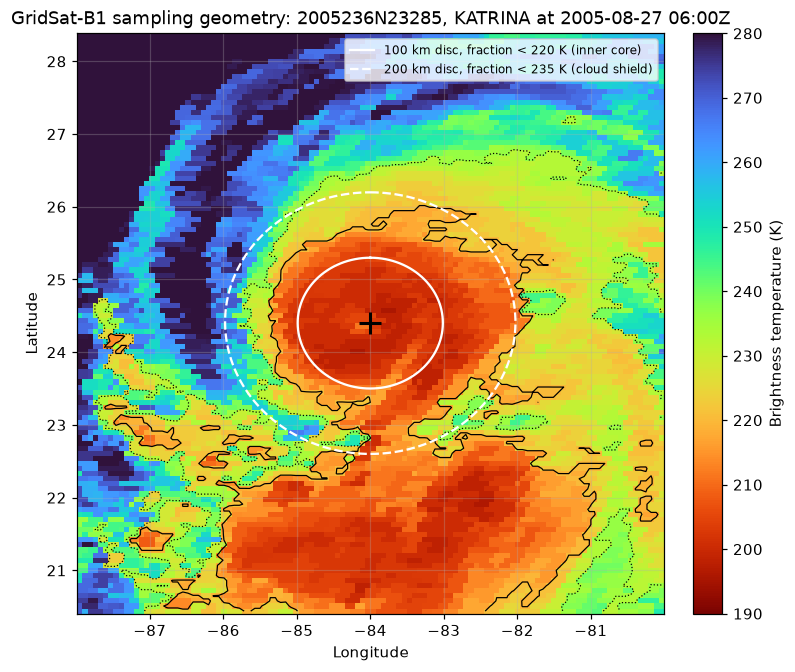

In [45]:
# @title GridSat-B1: Katrina: cold-cloud sampling geometry

plot_lat, plot_lon = example_storm_lat, example_storm_lon
plot_time = pd.Timestamp(example_storm_time)
plot_lon_180 = ((plot_lon + 180) % 360) - 180
domain_half_width = 4.0

gridsat_url = f"https://www.ncei.noaa.gov/data/geostationary-ir-channel-brightness-temperature-gridsat-b1/access/{plot_time:%Y}/GRIDSAT-B1.{plot_time:%Y.%m.%d.%H}.v02r01.nc"
gridsat_file = gridsat_url.split("/")[-1]
!wget -q -nc {gridsat_url}

gridsat_ds = xr.open_dataset(gridsat_file).isel(time=0).sel(lat=slice(plot_lat-domain_half_width, plot_lat+domain_half_width), lon=slice(plot_lon_180-domain_half_width, plot_lon_180+domain_half_width))

def create_distance_ring(distance_km, num_points=361):
    """Create a constant-distance circle around the storm center."""
    storm_lat_rad, storm_lon_rad = np.deg2rad(plot_lat), np.deg2rad(plot_lon_180)
    bearing_rad = np.deg2rad(np.linspace(0, 360, num_points))
    angular_distance = distance_km / EARTH_R_KM
    ring_lat_rad = np.arcsin(np.sin(storm_lat_rad)*np.cos(angular_distance) + np.cos(storm_lat_rad)*np.sin(angular_distance)*np.cos(bearing_rad))
    ring_lon_rad = storm_lon_rad + np.arctan2(np.sin(bearing_rad)*np.sin(angular_distance)*np.cos(storm_lat_rad), np.cos(angular_distance)-np.sin(storm_lat_rad)*np.sin(ring_lat_rad))
    return np.rad2deg(ring_lon_rad), np.rad2deg(ring_lat_rad)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
image = ax.pcolormesh(gridsat_ds.lon, gridsat_ds.lat, gridsat_ds.irwin_cdr.values, cmap="turbo_r", vmin=190, vmax=280)
fig.colorbar(image, ax=ax, label="Brightness temperature (K)")

ax.contour(gridsat_ds.lon, gridsat_ds.lat, gridsat_ds.irwin_cdr.values, levels=[220], colors="k", linewidths=0.8)
ax.contour(gridsat_ds.lon, gridsat_ds.lat, gridsat_ds.irwin_cdr.values, levels=[235], colors="k", linewidths=0.8, linestyles=":")

ax.plot(*create_distance_ring(100), "w-", lw=1.5, label="100 km disc, fraction < 220 K (inner core)")
ax.plot(*create_distance_ring(200), "w--", lw=1.5, label="200 km disc, fraction < 235 K (cloud shield)")
ax.plot(plot_lon_180, plot_lat, "k+", ms=14, mew=2)

ax.set(xlabel="Longitude", ylabel="Latitude", title=f"GridSat-B1 sampling geometry: {example_storm_id}, {example_storm_name} at {plot_time:%Y-%m-%d %H:%M}Z")
ax.legend(loc="upper right", fontsize=8)
plt.show()

---
### 3.2 Comparison of Precalculated and Derived GridSat features for Hurricane Katrina, Lat: 24.4°N Lon: 276.0°E, ISO Time: 2005-08-27T06:00

> **ℹ️ Minor Discrepancy**:
>
>Minor discrepancy in **cold cloud < 235K, 200km**, likely due to floating-point precision differences or slight variations in grid interpolation between the two computation environments.


In [46]:
mask = (
    (df_satellite["sid"] == example_storm_id)
    & (pd.to_datetime(df_satellite["iso_time"], utc=True) == pd.Timestamp(example_storm_time, tz="UTC"))
)
assert mask.sum() == 1, f"expected 1 matching row, got {mask.sum()}"
row = df_satellite[mask].iloc[0]
rows = [
    ("cold cloud < 220K, 100km", derived_100, row["cold_cloud_fraction_100km"]),
    ("cold cloud < 235K, 200km", derived_200, row["cold_cloud_fraction_200km"]),
]
comparison = pd.DataFrame(
    {"derived_in_the_notebook": [d for _, d, _ in rows],
     "precalculated":           [p for _, _, p in rows]},
    index=[n for n, _, _ in rows],
)
comparison.round(4)

,derived_in_the_notebook,precalculated
"cold cloud < 220K, 100km",1.0000,1.0000
"cold cloud < 235K, 200km",0.8883,0.8826


---
## 4. Merging IBTrACS, ERA5, and GridSAT features

Finally, we are ready to merge features from IBTrACS, ERA5, and GridSAT to make a meaningful tabular feature set, along with the target (`ri_tplus24`) which has been derived already in IBTrACS section.




### 🔍 A quick peek at all 3 feature tables

In [47]:
for name, df in [("IBTrACS", df_ibtracs), ("ERA5", df_era5), ("Satellite", df_satellite)]:
    print(f"\n{'='*200}\n{name}: {df.shape[0]:,} rows x {df.shape[1]} cols"
          f" | {df['sid'].nunique():,} storms")
    display(df.head(3))


IBTrACS: 78,472 rows x 33 cols | 4,105 storms


,sid,name,season,basin,full_basin_name,subbasin,iso_time,lat,lon,nature,track_type,iflag,usa_agency,usa_wind,usa_sshs,dist2land,storm_speed,lat_sin,lat_cos,lon_sin,lon_cos,abs_lat,doy_sin,doy_cos,usa_wind_tminus6h,usa_wind_delta_tminus6h,usa_wind_tminus12h,usa_wind_delta_tminus12h,usa_wind_tminus24h,usa_wind_delta_tminus24h,usa_wind_tplus24h,usa_wind_delta_tplus24h,ri_tplus24
0,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 00:00:00,-12.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,647,6.0,-0.216440,0.976296,0.130526,-0.991445,12.5,-0.017202,-0.999852,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.0,0
1,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 06:00:00,-11.9,172.4,TS,main,O_________OP_O_,jtwc_sh,25.0,-1,670,5.0,-0.206204,0.978509,0.132256,-0.991216,11.9,-0.017202,-0.999852,25.0,0.0,NaN,NaN,NaN,NaN,30.0,5.0,0
2,1980001S13173,PENI,1980,SP,Southern Pacific,MM,1980-01-01 12:00:00,-11.5,172.5,TS,main,O_________OO_O_,jtwc_sh,25.0,-1,703,4.0,-0.199368,0.979925,0.130526,-0.991445,11.5,-0.017202,-0.999852,25.0,0.0,25.0,0.0,NaN,NaN,35.0,10.0,0



ERA5: 78,472 rows x 16 cols | 4,105 storms


,sid,lat,lon,iso_time,sea_surface_temp_200km_mean,sst_valid_fraction,sea_level_pressure_200km_mean,column_water_vapour_200km_mean,annulus_cell_count,wind_east_200hPa_annulus_mean,wind_east_850hPa_annulus_mean,wind_north_200hPa_annulus_mean,wind_north_850hPa_annulus_mean,wind_shear_annulus_ms,wind_shear_annulus_kt,wind_shear_annulus_direction_deg
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,302.152889,1.0,100654.912905,57.328939,2490,8.488218,0.384507,-7.294214,-1.076515,10.214203,19.854822,127.497788
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,302.252015,1.0,100532.902639,59.203794,2486,6.548779,0.060527,-5.997417,-0.138075,8.742386,16.993838,132.084232
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,302.357574,1.0,100697.497443,58.608560,2484,7.122542,-1.377703,-5.689368,-0.259189,10.086675,19.606928,122.571505



Satellite: 78,472 rows x 7 cols | 4,105 storms


,sid,lat,lon,iso_time,cold_cloud_fraction_100km,cold_cloud_fraction_200km,ir_coverage_fraction
0,1980001S13173,-12.5,172.5,1980-01-01 00:00:00,NaN,NaN,0.742612
1,1980001S13173,-11.9,172.4,1980-01-01 06:00:00,0.007049,0.173876,1.000000
2,1980001S13173,-11.5,172.5,1980-01-01 12:00:00,0.999955,0.872292,1.000000


Let us define *ml_df*, indicating that the dataframe is ready for ML modeling.

*ml_df* will contain observations/records where *ri_tplus24* is defined such as 0/1. Rows where the 24-hour RI label cannot be determined (e.g. for storms at a timestamp where *t+24* record is unavailable), are already dropped.

In [48]:
df_era5 = df_era5.drop(columns=["lat", "lon"], errors="ignore")
df_satellite = df_satellite.drop(columns=["lat", "lon"], errors="ignore")

ml_df = (df_ibtracs
         .merge(df_era5, on=["sid", "iso_time"], how="left",
                validate="one_to_one", suffixes=("", "_DUP"))
         .merge(df_satellite, on=["sid", "iso_time"], how="left",
                validate="one_to_one", suffixes=("", "_DUP")))

dupes = [c for c in ml_df.columns if c.endswith("_DUP")]
assert not dupes, f"column collision in merge: {dupes}"

ml_df = ml_df[[c for c in ml_df.columns if c != TARGET] + [TARGET]]

---

## Train/Validation/Test Split

We split the data **by season**, rather than randomly:

* **Train: 1980–2010**: used to **teach the model** the relationship between the input features and RI.

* **Validation: 2011–2015**: used to **tune the model and choose settings**, such as the decision threshold, without using the final test data.

* **Test: 2016–2025**: used only at the end to **evaluate how well the trained model performs on unseen future storms**.

We do this because consecutive observations from the same storm are often very similar. With a random split, observations from the same storm (which are highly similar), could end up in both the training and test sets, making the model look better than it really is. This is a serious issue known as **data leakage**.

By splitting by season, **each storm stays in only one split**. This also better matches the real-world setting: we **train on past storms**, use the validation period to make modeling choices, and finally test whether the model can predict **future storms it has never seen before**.


In [49]:
def split(df):
    '''Chronological split by season. Never split randomly: storms are correlated
    within a season and a random split would leak.'''
    train = df[df.season <= TRAIN_END]
    validation = df[(df.season > TRAIN_END) & (df.season <= VAL_END)]
    test = df[(df.season > VAL_END) & (df.season <= TEST_END)]

    # Pairwise, not three-way: a two-way overlap must also fail
    assert not set(train.sid) & set(validation.sid), "train/val storm overlap"
    assert not set(train.sid) & set(test.sid), "train/test storm overlap"
    assert not set(validation.sid) & set(test.sid), "val/test storm overlap"

    for name, d in [("train", train), ("val", validation), ("test", test)]:
        print(f"{name:6s} seasons {int(d.season.min())}–{int(d.season.max())}  "
              f"rows={len(d):7,d}  storms={d.sid.nunique():5,d}  "
              f"ri_rate={d[TARGET].mean():.4f}")
    return train, validation, test

train  seasons 1980–2010  rows= 57,178  storms=2,816  ri_rate=0.0704
val    seasons 2011–2015  rows=  7,496  storms=  430  ri_rate=0.0986
test   seasons 2016–2025  rows= 13,798  storms=  859  ri_rate=0.1024


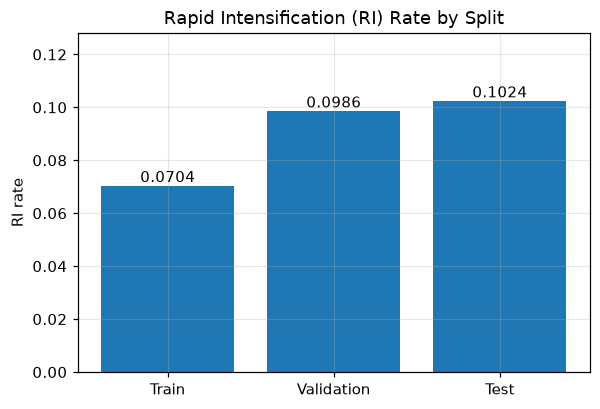

In [50]:
df_train, df_val, df_test = split(ml_df)

y_train = df_train[TARGET].astype(int)
y_val   = df_val[TARGET].astype(int)
y_test  = df_test[TARGET].astype(int)

train_base_rate = y_train.mean()
val_base_rate = y_val.mean()
test_base_rate = y_test.mean()

split_names = ["Train", "Validation", "Test"]
base_rates = [train_base_rate, val_base_rate, test_base_rate]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(split_names, base_rates)

ax.set_ylabel("RI rate")
ax.set_title("Rapid Intensification (RI) Rate by Split")
ax.set_ylim(0, max(base_rates) * 1.25)

for bar, rate in zip(bars, base_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{rate:.4f}", ha="center", va="bottom")

plt.show()

### RI % split by decade

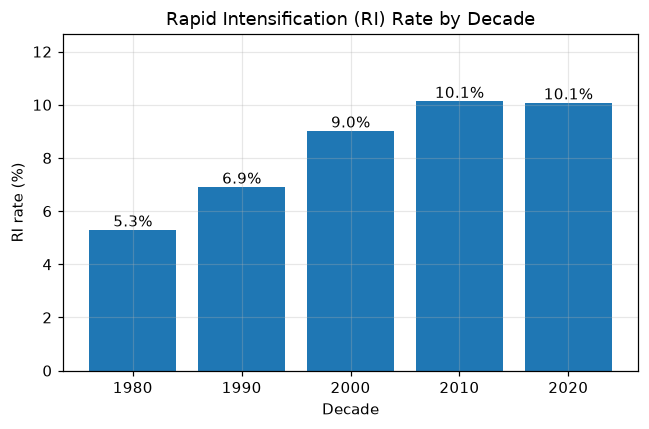

In [51]:
decade_ri = ml_df.assign(decade=pd.to_datetime(ml_df["iso_time"]).dt.year // 10 * 10).groupby("decade")[TARGET].mean() * 100

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(decade_ri.index.astype(str), decade_ri)

ax.set(xlabel="Decade", ylabel="RI rate (%)", title="Rapid Intensification (RI) Rate by Decade",
       ylim=(0, decade_ri.max() * 1.25))

for bar, rate in zip(bars, decade_ri):
    ax.text(bar.get_x() + bar.get_width()/2, rate, f"{rate:.1f}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

> #### ℹ️ Why Does the RI Rate Increase Over Time?
>
> The RI rate increases from **7.0% → 9.9% → 10.2%** across the train, validation, and test periods.
>
> Also, RI rate seems to increase drastically from 1980 to 2020 if you compare decade by decade rates.
>
>There are several possible reasons for this difference, but we should be careful not to assume that any single factor is responsible.
>
> * **Changing ocean conditions:** Warmer sea surface temperatures may create more favorable conditions for rapid intensification.
> * **Natural variability:** Tropical cyclone activity varies from year to year and across decades, so some periods may simply have more RI-favorable conditions.
> * **Changes in collection methods:** Satellite coverage, reconnaissance, and intensity estimation have improved over time, which may affect how RI events are recorded.
>
> For the model, the important point is that the RI rate is not constant over time. The model is trained on an earlier period with a lower RI rate and tested on later years with a higher rate. This creates a **distribution shift** between the training and test data, which can make generalization more challenging.
>
>**Further Reading:** Bhatia et al. (2019): [*Recent increases in tropical cyclone intensification rates*](https://www.nature.com/articles/s41467-019-08471-z), *Nature Communications* found a detectable increase in Atlantic TC intensification rates, with a positive contribution from anthropogenic forcing.


---
<a name="methodology"></a>

# Methodology

Rapid intensification (RI) is hard to predict because it depends on many factors acting together. Warm ocean water, low wind shear, and recent storm strengthening may each help, but their combination is often more important than any single factor alone.

This tutorial builds the prediction model step by step:

**Climatology → Linear model → Gradient-boosted model**

Each step adds more information and tests whether the model learns useful patterns beyond a simple baseline.

Main things considered before modelling:

* **Class imbalance:** RI makes up only **7.9%** of observations (about **1 RI for every 11.7 non-RI cases**). Simply predicting "no RI" gives high accuracy but is not useful.
* **Distribution shift:** The RI rate changes across time, from 7.0% in training (1980–2010) to 10.3% in the test period (2016–2025). The model therefore needs to work under a changing climatological baseline.
* **Data leakage:** Future wind information such as `usa_wind_tplus24h` and `usa_wind_delta_tplus24h` directly reveals the outcome. These variables are removed **before modeling** so the model only uses information available at prediction time.

We address these challenges throughout the tutorial and consider them again when evaluating the final model.

---

## Problem Definition

We treat RI as **binary classification problem at the observation level**. Given a feature vector $\mathbf{x}_t \in \mathbb{R}^{d}$ describing a storm's state at time $t$, the model outputs a probability

$$\hat{p}_t = P(y_t = 1 \mid \mathbf{x}_t)$$

where the label is

$$y_t = \mathbf{1}\!\left[\,w_{t+24} - w_t \;\geq\; 30\text{ kt}\,\right]$$

and $w_t$ is the maximum sustained 1-minute wind speed at time $t$. We predict
probabilities rather than hard labels because operational forecasters consume
probability guidance.

The features come from four source groups:
IBTrACS best-track, lagged wind history, ERA5 reanalysis, and satellite IR from GridSat-B1.



---
## 1. Defining features, target, ablation setup


### 1.1 Features and Target Definition

In machine learning, **features are the inputs** given to a model, and the **target is the output** we want it to predict. The model learns a mapping from the input features \(X\) to the target \(y\):

$$
X \rightarrow y
$$

For this task, the features describe the storm's current and past state and its surrounding environment, while the target indicates whether rapid intensification occurs within the next 24 hours. We organize the predictors into physically meaningful feature groups and exclude variables that contain information from the prediction period to avoid **data leakage**.


In [52]:
TARGET = "ri_tplus24"
GROUP  = "sid"
TIME   = "iso_time"

IBTRACS_BASE_FEATURES = [
    "usa_wind", "usa_sshs", "dist2land", "storm_speed",
    "lat_sin", "lat_cos", "lon_sin", "lon_cos", "abs_lat",
    "doy_sin", "doy_cos",
]

IBTRACS_PAST_TRENDS_FEATURES = [
    "usa_wind_tminus6h",  "usa_wind_delta_tminus6h",
    "usa_wind_tminus12h", "usa_wind_delta_tminus12h",
    "usa_wind_tminus24h", "usa_wind_delta_tminus24h",
]

ERA5_FEATURES = [
    "sea_surface_temp_200km_mean",
    "sea_level_pressure_200km_mean",
    "column_water_vapour_200km_mean",
    "wind_east_200hPa_annulus_mean",  "wind_north_200hPa_annulus_mean",
    "wind_east_850hPa_annulus_mean",  "wind_north_850hPa_annulus_mean",
    "wind_shear_annulus_ms",
]

SATELLITE_FEATURES = [
    "cold_cloud_fraction_100km",
    "cold_cloud_fraction_200km",
]

# NEVER features as these encode the future wind used to build the label.
LEAK = ["usa_wind_tplus24h", "usa_wind_delta_tplus24h"]

---
### 1.2 Feature Combinations for Ablation
Ablation systematically removes or adds groups of features to measure how much each source contributes to model performance. We compare individual feature groups, leave-one-group-out combinations, and the full feature set to understand which information sources are most useful for RI prediction.

#### Feature Groups
We define four mutually exclusive groups:

- **Base**: Current storm-state variables from IBTrACS
- **Trends**: Past-window trend features derived from IBTrACS
- **ERA5**: Large-scale atmospheric reanalysis fields
- **Satellite**: Satellite-derived observations

#### Combination Strategy
Experiments follow three configurations:

(1) **single-group**: isolating each group's individual contribution

(2) **leave-one-group-out (LOGO)**: revealing the marginal value of each source when the remaining three are present

(3) **full feature set**: serving as the performance ceiling.

This yields 9 configurations in total, all evaluated under identical train/validation/test splits and random seeds

In [53]:
FEATURE_SETS = {
    # Single sources: what does each know on its own?
    "base":       IBTRACS_BASE_FEATURES,
    "trends":     IBTRACS_PAST_TRENDS_FEATURES,
    "era5":       ERA5_FEATURES,
    "sat":        SATELLITE_FEATURES,

    # Leave-one-out: what does each add at the margin?
    "all-minus-base":   IBTRACS_PAST_TRENDS_FEATURES + ERA5_FEATURES + SATELLITE_FEATURES,
    "all-minus-trends": IBTRACS_BASE_FEATURES + ERA5_FEATURES + SATELLITE_FEATURES,
    "all-minus-era5":   IBTRACS_BASE_FEATURES + IBTRACS_PAST_TRENDS_FEATURES + SATELLITE_FEATURES,
    "all-minus-sat":    IBTRACS_BASE_FEATURES + IBTRACS_PAST_TRENDS_FEATURES + ERA5_FEATURES,

    # All features in consideration
    "all":        IBTRACS_BASE_FEATURES + IBTRACS_PAST_TRENDS_FEATURES
                  + ERA5_FEATURES + SATELLITE_FEATURES,
}

---
### 1.3 Dataset Split Summary

In [54]:
BASE_RATE        = float(y_train.mean())
POS_CLASS_WEIGHT = float((y_train == 0).sum() / (y_train == 1).sum())

total_n = len(df_train) + len(df_val) + len(df_test)
total_storms = (
    df_train[GROUP].nunique()
    + df_val[GROUP].nunique()
    + df_test[GROUP].nunique()
)

summary = pd.DataFrame([
    dict(split="train", years="1980-2010", n=len(df_train),
         storms=df_train[GROUP].nunique(), ri_percentage=100*y_train.mean()),
    dict(split="val",   years="2011-2015", n=len(df_val),
         storms=df_val[GROUP].nunique(), ri_percentage=100*y_val.mean()),
    dict(split="test",  years="2016-2025", n=len(df_test),
         storms=df_test[GROUP].nunique(), ri_percentage=100*y_test.mean()),
])
summary["n_percentage"] = 100 * summary["n"] / total_n
summary["storm_percentage"] = 100 * summary["storms"] / total_storms
summary = summary[
    ["split", "years", "n", "n_percentage", "storms", "storm_percentage", "ri_percentage"]
]

display(summary.round(2))
print(f"training base rate = {BASE_RATE:.4f}")
print(f"training pos-class weight = {POS_CLASS_WEIGHT:.2f}")

,split,years,n,n_percentage,storms,storm_percentage,ri_percentage
0,train,1980-2010,57178,72.86,2816,68.60,7.04
1,val,2011-2015,7496,9.55,430,10.48,9.86
2,test,2016-2025,13798,17.58,859,20.93,10.24


training base rate = 0.0704
training pos-class weight = 13.21


---

### 💡 Concept: How do we know if an ML model is actually good?

A model can perform well on the data it was trained on. But the real question is:

**How well will it work on data it has never seen before?**

That is why we use evaluation metrics. Each metric tells us something different about the model. No single evaluation metric tells the whole story, but a combination of them will help us evaluate the model better, optimized for the metric that we care about most.

### Why Accuracy Fails for RI Prediction

---

### The Core Problem: RI Events Are Rare

Rapid intensification is relatively uncommon. Most storm observations are **non-RI**.

This creates **class imbalance**: one class is much more common than the other.

Because of this, accuracy can be misleading.

---

### Why Accuracy Can Be Misleading

**Accuracy** is the fraction of predictions that are correct:

$$
\text{Accuracy} = \frac{TP + TN}{\text{All cases}}
$$

Suppose we have:

* **100 RI events** (10%)
* **900 non-RI events** (90%)

A model that always predicts **"No RI"** gets:

$$
\text{Accuracy} = \frac{900}{1000} = 90\%
$$

That sounds good, but the model **misses every RI event**.

For RI prediction, we therefore need metrics that focus more on the rare RI class.

---

### The Confusion Matrix

A confusion matrix shows four possible outcomes:

|                  |   **Predicted RI**   |     **Predicted No RI**     |
| ---------------- | :------------------: | :-------------------------: |
| **Actual RI**    | **TP**: detected RI |      **FN**: missed RI     |
| **Actual No RI** | **FP**: false alarm | **TN**: correctly rejected |

These four numbers are used to calculate most of our evaluation metrics.

### Running Example

Suppose our model makes these predictions for 1,000 observations:

|                  | **Predicted RI** | **Predicted No RI** |
| ---------------- | :--------------: | :-----------------: |
| **Actual RI**    |      TP = 60     |       FN = 40       |
| **Actual No RI** |      FP = 50     |       TN = 850      |

So the model:

* catches **60 of 100 RI events**
* misses **40 RI events**
* gives **50 false alarms**
* correctly identifies **850 non-RI cases**

---

## The Metrics That Matter

#### 1. Recall: "Did we catch the RI events?"

Also called **Hit Rate** or **Probability of Detection (POD)**.

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

For our example:

$$
\frac{60}{60+40} = 0.60
$$

The model catches **60% of the RI events**.

**Higher Recall is better.**

---

#### 2. Precision: "When we predicted RI, were we right?"

Also called the **Success Ratio**.

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

$$
\frac{60}{60+50} \approx 0.545
$$

About **55% of the RI warnings were correct**.

**Higher Precision is better.**

---

#### 3. False Alarm Ratio (FAR): "How many warnings were wrong?"

$$
\text{FAR} = \frac{FP}{TP + FP} = 1-\text{Precision}
$$

$$
\frac{50}{60+50} \approx 0.455
$$

About **45.5% of the RI warnings were false alarms**.

**Lower FAR is better.**

FAR is different from **POFD** because FAR looks only at predicted RI cases.

---

#### 4. Probability of False Detection (POFD): "How often did we falsely flag a non-RI case?"


$$
\text{POFD} = \frac{FP}{FP + TN}
$$

$$
\frac{50}{50+850} \approx 0.056
$$

The model incorrectly flags about **5.6% of non-RI cases**.

**Lower POFD is better.**

#### FAR vs POFD

| Metric   | What does it ask?                                     |
| -------- | ----------------------------------------------------- |
| **FAR**  | Of our RI warnings, how many were wrong?              |
| **POFD** | Of actual non-RI cases, how many did we falsely flag? |

---

#### 5. Critical Success Index (CSI): "How well did we handle the RI cases?"

Also called the **Threat Score**.

$$
\text{CSI} = \frac{TP}{TP + FP + FN}
$$

CSI counts:

* correctly predicted RI (**TP**)
* missed RI (**FN**)
* false alarms (**FP**)

It ignores TN because non-RI cases are very common.

$$
\text{CSI} = \frac{60}{60+50+40} = 0.40
$$

**Higher CSI is better.**

---

#### 6. F1 Score: "How well do we balance precision and recall?"

$$
\text{F1} =
\frac{2 \times \text{Precision} \times \text{Recall}}
{\text{Precision}+\text{Recall}}
$$

For our example:

$$
\text{F1} \approx 0.571
$$

F1 gives **equal importance to precision and recall**.

**Higher F1 is better.**

---

#### 7. F2 Score: "What if catching RI matters more (recall weighs more)?"

F2 is similar to F1 but gives **more weight to recall**.

$$
\text{F2} =
\frac{5 \times \text{Precision} \times \text{Recall}}
{4 \times \text{Precision}+\text{Recall}}
$$

For our example:

$$
\text{F2} \approx 0.588
$$

This can be useful for RI because **missing an RI event may be more concerning than issuing a false alarm**.

**Higher F2 is better.**

---

#### 8. Brier Skill Score: "Are our predicted probabilities any good?"

Most metrics tell us how good the **final decision** is: RI or no RI.

The **Brier Score** looks at something different: **how good our predicted probabilities are**.

$$
\text{BS} = \frac{1}{N}\sum_{i=1}^{N}(p_i-y_i)^2
$$

A lower Brier Score (BS) is better. But since RI is rare, we should compare our model against a simple baseline that always predicts the **RI base rate**.

$$
\text{BSS} = 1 - \frac{\text{BS}}{\text{BS}_{\text{ref}}}
$$

For example, if the RI rate is 10%, always predicting $p=0.10$ gives:

$$
\text{BS}_{\text{ref}} = 0.09
$$

If our model gets $\text{BS}=0.06$:

$$
\text{BSS} = 1-\frac{0.06}{0.09} \approx 0.33
$$

This means our model's probability predictions are **better than simply using the 10% RI rate for every case**.

|   BSS   | Meaning                     |
| :-----: | --------------------------- |
| **1.0** | Perfect                     |
|  **0**  | No better than the baseline |
| **< 0** | Worse than the baseline     |

**Higher BSS is better.**

---

### All Metrics, Side by Side

| Metric          | Formula                      |   Best  | What does it tell us?                                 |
| --------------- | ---------------------------- | :-----: | ----------------------------------------------------- |
| ~~Accuracy~~    | (TP+TN) / All                | ~~1.0~~ | Can be misleading for rare RI events                  |
| **Recall**      | TP / (TP+FN)                 |   1.0   | How many RI events did we catch?                      |
| **Precision**   | TP / (TP+FP)                 |   1.0   | How many RI warnings were correct?                    |
| **FAR**         | FP / (TP+FP)                 |   0.0   | How many RI warnings were false alarms?               |
| **POFD**        | FP / (FP+TN)                 |   0.0   | How often did we falsely flag non-RI?                 |
| **CSI**         | TP / (TP+FP+FN)              |   1.0   | How well did we handle the RI cases?                  |
| **F1**          | 2PR / (P+R)                  |   1.0   | How well are precision and recall balanced?           |
| **F2**          | 5PR / (4P+R)                 |   1.0   | How well do we balance them when recall matters more? |
| **Brier Skill Score** | $1 - \text{BS}/\text{BS}_{\text{ref}}$ | 1.0 | Do our probabilities beat the base-rate baseline? |

---
## 2. Helper Functions (Method Definitions)

All function definitions are kept together in this section.

Nothing is executed here. We are only defining the functions that will be used later. This keeps the actual modeling phase less cluttered and easier to follow.


### 2.1 Evaluation Metrics

`evaluate()` calculates threshold-free metrics such as PR-AUC, ROC-AUC, and Brier Skill Score, which measure how well the model **ranks** observations. `confusion()` calculates metrics that depend on choosing a specific probability cutoff.


In [55]:
# @title Functions to evaluate ML model
def evaluate(model_name, y_true, probabilities, base_rate=None):
    """Ranking metrics plus Brier Skill Score against the climatological forecast."""
    base_rate     = BASE_RATE if base_rate is None else base_rate
    y_true        = np.asarray(y_true).astype(int)
    probabilities = np.asarray(probabilities, dtype=float)

    brier_model    = brier_score_loss(y_true, probabilities)
    brier_baseline = brier_score_loss(y_true, np.full_like(probabilities, base_rate))

    results = dict(
        model   = model_name,
        pr_auc  = average_precision_score(y_true, probabilities),
        roc_auc = roc_auc_score(y_true, probabilities),
        bss     = 1 - brier_model / brier_baseline,
    )
    print(f"{model_name:26s} PR-AUC={results['pr_auc']:.4f}  "
          f"ROC-AUC={results['roc_auc']:.4f}  BSS={results['bss']:+.4f}")
    return results


def confusion(y_true, probabilities, threshold, title=""):
    """Calculate classification counts and threshold-based scores."""
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

    recall    = tp / (tp + fn) if tp + fn else 0.0
    precision = tp / (tp + fp) if tp + fp else 0.0
    far       = 1 - precision
    pofd      = fp / (fp + tn) if fp + tn else 0.0
    csi       = tp / (tp + fp + fn) if tp + fp + fn else 0.0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    f2        = 5 * precision * recall / (4 * precision + recall) if 4 * precision + recall else 0.0

    # Formatting variables
    title_str = title if title else "Classification Report"
    print(f"\n{'=' * 100}")
    print(f"{title_str} | Threshold: {threshold:.3f}")
    print(f"{'=' * 100}")
    print("Confusion Matrix:")
    print(f"  TP: {tp:<12,}  FN: {fn:<12,}")
    print(f"  FP: {fp:<12,}  TN: {tn:<12,}")
    print(f"{'-' * 100}")
    print("Performance Scores:")
    print(f"  Recall:    {recall:<10.3f} Precision: {precision:<10.3f}")
    print(f"  F1 Score:  {f1:<10.3f} F2 Score:  {f2:<10.3f}")
    print(f"  CSI:       {csi:<10.3f} FAR:       {far:<10.3f}")
    print(f"{'=' * 100}\n")

    return dict(tn=tn, fp=fp, fn=fn, tp=tp,
                recall=recall, precision=precision, far=far,
                csi=csi, f1=f1, f2=f2)

In [56]:
# @title Function to plot Confusion Matrix (CM)
PASTEL_GREEN = "#a8d5b5"
PASTEL_RED   = "#f0a8a8"

def plot_confusion(y_true, probabilities, threshold, title=""):
    """Confusion matrix: green for correct cells, red for errors."""
    y_true = np.asarray(y_true).astype(int)
    preds = (np.asarray(probabilities) >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds, labels=[1, 0])

    correct = np.array([[True, False], [False, True]])
    labels = [["TP", "FN"], ["FP", "TN"]]

    fig, ax = plt.subplots(figsize=(4.2, 3.8))

    for i in range(2):
        for j in range(2):
            ax.add_patch(plt.Rectangle(
                (j - 0.5, i - 0.5), 1, 1,
                facecolor=PASTEL_GREEN if correct[i, j] else PASTEL_RED,
                edgecolor="white", linewidth=2
            ))
            ax.text(j, i, f"{labels[i][j]}\n{cm[i, j]:,}",
                    ha="center", va="center", color="#222222", fontsize=12)

    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_xticks([0, 1], ["RI", "No RI"])
    ax.set_yticks([0, 1], ["RI", "No RI"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Observed")
    ax.set_title(f"{title}\n(threshold = {threshold:.3f})")
    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

    return cm

---
### 2.2 Baseline Models

We use two simple reference models to put the learned models into context. `fit_climatology` ignores all storm information and predicts using only the overall RI frequency. `fit_wind_trend` uses a simple physical intuition: **storms that have recently been intensifying are more likely to continue intensifying**. It uses only the storm's recent wind trend as its predictor.


In [57]:
# @title Functions to define baseline models
def fit_climatology(X_train, y_train, X_val=None, y_val=None):
    """Always predicts the training base rate. The floor every model must beat."""
    return DummyClassifier(strategy="prior").fit(X_train, y_train)


def fit_wind_trend(X_train, y_train, verbose=True):
    """Find the 6-hour wind-trend threshold that maximises CSI on training data.
    NaNs (first observation of each storm, no prior history) are filled with 0
    """
    col = X_train["usa_wind_delta_tminus6h"].fillna(0.0)
    best_csi, best_threshold = -1.0, 0.0

    for t in np.arange(0, 25, 0.5):
        y_pred = (col >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_train, y_pred, labels=[0, 1]).ravel()
        csi = tp / max(tp + fp + fn, 1)
        if csi > best_csi:
            best_csi, best_threshold = csi, t

    if verbose:
        print(f"  wind-trend rule:  delta_w(-6h) >= {best_threshold:.1f} kt   "
              f"(train CSI = {best_csi:.4f})")
    return best_threshold


def predict_proba_wind_trend(X, wind_threshold):
    """Hard rule, so probabilities are degenerate (0 or 1).
    """
    p = (X["usa_wind_delta_tminus6h"].fillna(0.0) >= wind_threshold).astype(float).values
    return np.column_stack([1 - p, p])

---
### 2.3 Learned Models

We use two learned models with different levels of complexity. **Logistic regression** provides a simple, interpretable linear baseline, while **XGBoost** can capture nonlinear relationships and interactions between features.

**Logistic regression**: a linear model that estimates the probability of RI from a weighted combination of the input features. Its coefficients provide a useful indication of how individual features are associated with the prediction.

Because it cannot handle missing values directly, we use median imputation and standardisation before training.

| Parameter      | Value      | Reason                                               |
| -------------- | ---------- | ---------------------------------------------------- |
| `class_weight` | `balanced` | Gives more weight to the less frequent RI cases      |
| `max_iter`     | 2000       | Provides enough iterations for the model to converge |

**XGBoost**: a tree-based model that learns nonlinear relationships and interactions between features. This is useful here because RI can depend on combinations of conditions, e.g. ocean temperature, wind shear, and cloud structure together. XGBoost can also handle missing values natively.

We keep the XGBoost hyperparameters **fixed rather than tuning them separately for each feature set**. This keeps the ablation experiment focused on one question: **does adding a particular feature group improve the model?** It avoids changing the model configuration at the same time, which would make the comparisons harder to interpret.

| Parameter          | Value   | Reason                                                              |
| ------------------ | ------- | ------------------------------------------------------------------- |
| `max_depth`        | 4       | Keeps trees relatively simple and reduces overfitting               |
| `learning_rate`    | 0.05    | Makes smaller updates during training                               |
| `min_child_weight` | 10      | Discourages very small, highly specific leaves                      |
| `subsample`        | 0.8     | Uses a random subset of rows for each boosting step                 |
| `colsample_bytree` | 0.8     | Uses a random subset of features for each tree                      |
| `scale_pos_weight` | 13.2    | Gives greater weight to the less frequent RI class                  |
| `eval_metric`      | `aucpr` | Focuses evaluation on performance for the imbalanced positive class |

Both models account for **class imbalance** during training because RI events are much less common than non-RI cases.


In [58]:
# @title Functions to fit logistic regression and xgboost
def fit_logistic(X_train, y_train, X_val=None, y_val=None):
    """Linear baseline. Median imputation + standardisation + balanced class weights."""
    return Pipeline([
        ("imputer",  SimpleImputer(strategy="median")),
        ("scaler",   StandardScaler()),
        ("logistic", LogisticRegression(class_weight="balanced",
                                        max_iter=2000, random_state=SEED)),
    ]).fit(X_train, y_train)


def fit_xgboost(X_train, y_train, X_val=None, y_val=None, n_estimators=600):
    """Gradient-boosted trees. Handles NaN natively, no imputation needed.

    Early stopping is used only when validation data is supplied (CV folds).
    The Phase 2 refit passes n_estimators explicitly and stops there.
    """
    use_early_stop = X_val is not None

    model = XGBClassifier(
        n_estimators          = n_estimators,
        max_depth             = 4,
        learning_rate         = 0.05,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_weight      = 10,
        reg_lambda            = 2.0,
        scale_pos_weight      = POS_CLASS_WEIGHT,
        eval_metric           = "aucpr",
        early_stopping_rounds = 40 if use_early_stop else None,
        n_jobs                = -1,
        random_state          = SEED,
    )

    if use_early_stop:
        return model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return model.fit(X_train, y_train, verbose=False)

MODEL_FNS = {"logistic": fit_logistic, "xgboost": fit_xgboost}

---
### 2.4 Cross-Validation Strategy

We use **`GroupKFold` with storm ID as the group key**, keeping all observations from the same storm in a single fold.

This prevents information from highly correlated time steps of the same storm from appearing in both training and validation data. Standard k-fold could therefore give overly optimistic results.


In [59]:
# @title Function to run GroupKFold cross validation on training data
def run_cv_grid(df_train, y_train, feature_sets, model_fns, n_splits=5):
    """GroupKFold CV over every (feature set x model) pair, ranked by mean PR-AUC.

    Also records mean best_iteration per XGBoost row so that we can refit
    without early stopping.
    """
    cv, groups, rows = GroupKFold(n_splits), df_train[GROUP].values, []

    for fs_name, features in feature_sets.items():
        X = df_train[features]
        for model_name, fit_fn in model_fns.items():
            scores, iters = [], []
            print(f"Evaluating feature set: {fs_name} | model: {model_name}")
            for tr_idx, va_idx in cv.split(X, y_train, groups=groups):
                y_va  = y_train.iloc[va_idx]
                model = fit_fn(X.iloc[tr_idx], y_train.iloc[tr_idx], X.iloc[va_idx], y_va)
                scores.append(average_precision_score(
                    y_va, model.predict_proba(X.iloc[va_idx])[:, 1]))
                if getattr(model, "best_iteration", None) is not None:
                    iters.append(model.best_iteration)

            rows.append(dict(feature_set=fs_name, model=model_name,
                             pr_auc_mean=np.mean(scores), pr_auc_std=np.std(scores),
                             best_iter=int(np.mean(iters)) if iters else 600))

    return (pd.DataFrame(rows).sort_values("pr_auc_mean", ascending=False)
              .reset_index(drop=True))

---
### 2.5 Calibration and threshold selection

`scale_pos_weight` improves discrimination but inflates the raw probabilities.

Isotonic regression corrects that distortion. So, a predicted 0.30 corresponds to a ~30% observed RI rate. `report_alarm_rates` then shows the Recall/FAR trade-off across candidate cutoffs, and `best_threshold` picks one. All three are fitted or evaluated on **validation data only**.

In [60]:
# @title Functions for calibration and threshold selection

def fit_calibrator(val_scores, y_val):
    """Isotonic calibration map. Apply to new scores with .predict(scores)."""
    return IsotonicRegression(out_of_bounds="clip").fit(val_scores, y_val)


def best_threshold(y_true, probabilities, beta=2.0):
    """F-beta optimal threshold. beta=2 weights recall twice as heavily as
    precision, reflecting that a missed RI event is costlier than a false alarm."""
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    b2    = beta ** 2
    fbeta = (1 + b2) * precision * recall / np.clip(b2 * precision + recall, 1e-9, None)
    return float(thresholds[np.nanargmax(fbeta[:-1])])


def report_alarm_rates(y_true, probabilities, alarm_rates=(0.30, 0.20, 0.10, 0.05)):
    """Skill at different fractions of observations flagged."""
    header = (f"{'Threshold':>9}  {'Alarm%':>6}  {'Recall':>6}  "
              f"{'Precision':>9}  {'F1':>6}  {'F2':>6}  {'FAR':>6}  {'CSI':>6}")
    print(f"\n{header}\n{'-' * len(header)}")

    for alarm_rate in alarm_rates:
        threshold   = float(np.quantile(probabilities, 1 - alarm_rate))
        predictions = (probabilities >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()

        recall    = tp / max(tp + fn, 1)
        precision = tp / max(tp + fp, 1)
        f1        = 2 * precision * recall / max(precision + recall, 1e-12)
        f2        = 5 * precision * recall / max(4 * precision + recall, 1e-12)
        far       = 1 - precision
        csi       = tp / max(tp + fp + fn, 1)

        print(f"{threshold:9.3f}  {alarm_rate*100:5.0f}%  {recall:6.3f}  "
              f"{precision:9.3f}  {f1:6.3f}  {f2:6.3f}  "
              f"{far:6.3f}  {csi:6.3f}")

---
### 2.6 Error-analysis reporting

In [61]:
# @title Function to report metrics by group
def report_by_group(df, y_true, probabilities, group_col, min_events=5):
    """PR-AUC broken down by any grouping column
    """
    y_true = np.asarray(y_true)
    rows   = []

    for key in sorted(df[group_col].unique()):
        mask = (df[group_col] == key).values
        if y_true[mask].sum() < min_events:
            continue
        base   = y_true[mask].mean()
        pr_auc = average_precision_score(y_true[mask], probabilities[mask])
        rows.append({group_col: key,
                     "storms":  df.loc[mask, GROUP].nunique(),
                     "obs":     mask.sum(),
                     "RI":      int(y_true[mask].sum()),
                     "RI %":    100 * base,
                     "PR-AUC":  pr_auc,
                     "vs base": pr_auc / base})
    out = pd.DataFrame(rows).set_index(group_col)

    return (out.style
              .format({"storms": "{:,.0f}", "obs": "{:,.0f}", "RI": "{:,.0f}",
                       "RI %": "{:.1f}%", "PR-AUC": "{:.3f}", "vs base": "{:.1f}x"})
              .background_gradient(cmap="Greens", subset=["PR-AUC"], vmin=0, vmax=0.6)
              .set_caption(f"Skill by {group_col} (test set)"))

---
## 3. Model Development

### 3.1 Feature Set & Model Selection

We evaluate every model and feature-set combination using **5-fold `GroupKFold`**, strictly within the training set.

GroupKFold gives a reliable comparison of models and feature sets by evaluating them across multiple subsets (here 5) of the training data.

Storm ID is used as the group key, so observations from the same storm never appear in both the training and validation fold.

Each combination is compared using its **mean PR-AUC across the 5 folds**. The best-performing combination becomes the **champion configuration**. The validation set remains completely untouched during this phase.


In [62]:
# This cell might take ~3-4 minutes to run completely
cv_results = run_cv_grid(df_train, y_train, FEATURE_SETS, MODEL_FNS, n_splits=5)
display(cv_results.round(4))

Evaluating feature set: base | model: logistic
Evaluating feature set: base | model: xgboost
Evaluating feature set: trends | model: logistic
Evaluating feature set: trends | model: xgboost
Evaluating feature set: era5 | model: logistic
Evaluating feature set: era5 | model: xgboost
Evaluating feature set: sat | model: logistic
Evaluating feature set: sat | model: xgboost
Evaluating feature set: all-minus-base | model: logistic
Evaluating feature set: all-minus-base | model: xgboost
Evaluating feature set: all-minus-trends | model: logistic
Evaluating feature set: all-minus-trends | model: xgboost
Evaluating feature set: all-minus-era5 | model: logistic
Evaluating feature set: all-minus-era5 | model: xgboost
Evaluating feature set: all-minus-sat | model: logistic
Evaluating feature set: all-minus-sat | model: xgboost
Evaluating feature set: all | model: logistic
Evaluating feature set: all | model: xgboost


,feature_set,model,pr_auc_mean,pr_auc_std,best_iter
0,all,xgboost,0.4012,0.0254,205
1,all-minus-sat,xgboost,0.3887,0.0198,197
2,all-minus-base,xgboost,0.3838,0.0247,138
3,all-minus-trends,xgboost,0.3678,0.0229,218
4,all-minus-era5,xgboost,0.3523,0.0183,201
5,all,logistic,0.3008,0.0154,600
6,all-minus-base,logistic,0.2917,0.0153,600
7,all-minus-sat,logistic,0.2777,0.0139,600
8,trends,xgboost,0.2752,0.0202,81
9,all-minus-era5,logistic,0.2591,0.0107,600


In [63]:
best_result = cv_results.iloc[0]

BEST_MODEL_NAME     = best_result.model
BEST_FEATURES       = FEATURE_SETS[best_result.feature_set]
BEST_N_ESTIMATORS   = int(best_result.best_iter)

print("Best configuration:")
print(f"  model        : {BEST_MODEL_NAME}")
print(f"  feature set  : {best_result.feature_set}  ({len(BEST_FEATURES)} features)")
print(f"  CV PR-AUC    : {best_result.pr_auc_mean:.4f} +/- {best_result.pr_auc_std:.4f}")
print(f"  n_estimators : {BEST_N_ESTIMATORS}")

Best configuration:
  model        : xgboost
  feature set  : all  (27 features)
  CV PR-AUC    : 0.4012 +/- 0.0254
  n_estimators : 205


>### Ablation: what does each data source add?
>
>The same model comparison can also be used for **feature ablation**. By comparing XGBoost performance across different feature sets, we can see how much each data source contributes to RI prediction.

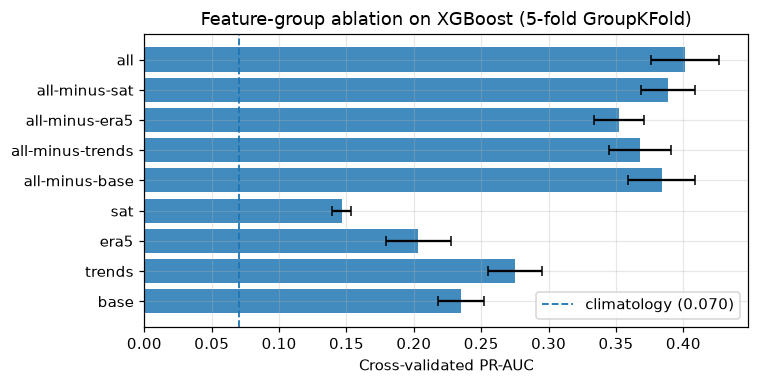

In [64]:
xgboost_results = cv_results[cv_results.model == "xgboost"].set_index("feature_set").reindex(FEATURE_SETS)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(xgboost_results.index, xgboost_results.pr_auc_mean, xerr=xgboost_results.pr_auc_std, alpha=0.85, capsize=3)
ax.axvline(BASE_RATE, ls="--", lw=1.2, label=f"climatology ({BASE_RATE:.3f})")
ax.set_xlabel("Cross-validated PR-AUC")
ax.set_title("Feature-group ablation on XGBoost (5-fold GroupKFold)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

---
### 3.2 Full Refit on Training Data

Retrain the best configuration on the **entire** training set.

For XGBoost we pass the mean `best_iteration` recorded across the cross-validation folds (`n-estimators`) rather than using early stopping. There is no held-out fold to stop against
here, and borrowing the validation set for that purpose would spend it before
Phase 3 needs it.

In [65]:
X_train_best = df_train[BEST_FEATURES]
X_val_best   = df_val[BEST_FEATURES]
X_test_best  = df_test[BEST_FEATURES]

if BEST_MODEL_NAME == "xgboost":
    best_model = fit_xgboost(X_train_best, y_train, n_estimators=BEST_N_ESTIMATORS)
else:
    best_model = MODEL_FNS[BEST_MODEL_NAME](X_train_best, y_train)

print(f"Refit {BEST_MODEL_NAME} on {len(X_train_best):,} rows "
      f"x {len(BEST_FEATURES)} features.")

Refit xgboost on 57,178 rows x 27 features.


### Reference Baselines

Simple reference models fitted on the same training data, providing a baseline for comparing the learned models.


In [66]:
climatology_model = fit_climatology(X_train_best, y_train)
wind_threshold    = fit_wind_trend(df_train, y_train, verbose = False)
logistic_model    = fit_logistic(X_train_best, y_train)

---
### 3.3 Probability Calibration

We now use the **validation set** for the first time. The best model produces raw probability scores, and we use **isotonic regression** to calibrate them.

**Isotonic regression** is a simple method that learns how to adjust the model's raw scores into more realistic probabilities, while keeping their **order** the same.

For example, if the model gives a group of cases a score around **0.7**, calibration checks whether those cases actually have an RI rate close to **70%** and adjusts the scores accordingly.

This is useful because `scale_pos_weight` can make the model's raw probabilities too high.

**PR-AUC and ROC-AUC measure ranking, not probability accuracy.** Calibration changes the probability values but keeps their **ranking** the same, so these metrics remain unchanged.


In [67]:
val_scores = best_model.predict_proba(X_val_best)[:, 1]
calibrator = fit_calibrator(val_scores, y_val)
val_probs  = calibrator.predict(val_scores)

_ = evaluate("validation (raw)",        y_val, val_scores)
_ = evaluate("validation (calibrated)", y_val, val_probs)

validation (raw)           PR-AUC=0.4733  ROC-AUC=0.8697  BSS=-0.7869
validation (calibrated)    PR-AUC=0.4609  ROC-AUC=0.8732  BSS=+0.2597


#### 3.3.1 Reliability Diagram

A perfectly calibrated model follows the diagonal. For example, when it predicts **0.3**, about **30% of those cases** should actually be RI.

The raw predictions fall well below the diagonal. For example, when the model predicts **0.74**, only **21%** of those cases are RI. This happens because `scale_pos_weight` gives RI cases much more weight during training, making the raw probabilities too high. The model can still rank cases well, so ROC-AUC and PR-AUC are largely unaffected.

The calibrated curve is much closer to the diagonal because isotonic regression adjusts the probabilities using the validation data. Since it was fitted on this same data, this diagram shows the **calibration fit**, not an independent test.

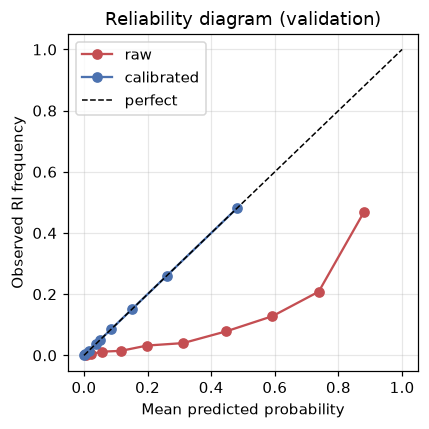

In [68]:
fig, ax = plt.subplots(figsize=(4, 4))
for scores, label, colour in [(val_scores, "raw", "#C44E52"),
                              (val_probs,  "calibrated", "#4C72B0")]:
    frac_pos, mean_pred = calibration_curve(y_val, scores, n_bins=10, strategy="quantile")
    ax.plot(mean_pred, frac_pos, "o-", color=colour, label=label)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed RI frequency")
ax.set_title("Reliability diagram (validation)")
ax.legend()
plt.tight_layout()
plt.show()

---
### 3.4 Threshold Selection

We use the calibrated validation probabilities to choose a single threshold for classifying cases as RI or non-RI.

We use F-beta with `beta = 2` (also known as F2), which puts more weight on recall than precision. This is because **missing an actual RI event is generally more concerning than raising a false alarm**. A false positive can be followed up with further monitoring, while a missed RI event could mean less time to prepare for rapid strengthening.

This is the second and final use of the validation set.


In [69]:
report_alarm_rates(y_val, val_probs)


Threshold  Alarm%  Recall  Precision      F1      F2     FAR     CSI
--------------------------------------------------------------------
    0.102     30%   0.861      0.251   0.389   0.580   0.749   0.242
    0.167     20%   0.717      0.332   0.454   0.582   0.668   0.294
    0.310     10%   0.498      0.463   0.480   0.491   0.537   0.316
    0.392      5%   0.345      0.569   0.430   0.375   0.431   0.274


F1-optimal decision threshold = 0.244

Best result on VALIDATION @ F1 threshold | Threshold: 0.244
Confusion Matrix:
  TP: 428           FN: 311         
  FP: 601           TN: 6,156       
----------------------------------------------------------------------------------------------------
Performance Scores:
  Recall:    0.579      Precision: 0.416     
  F1 Score:  0.484      F2 Score:  0.537     
  CSI:       0.319      FAR:       0.584     



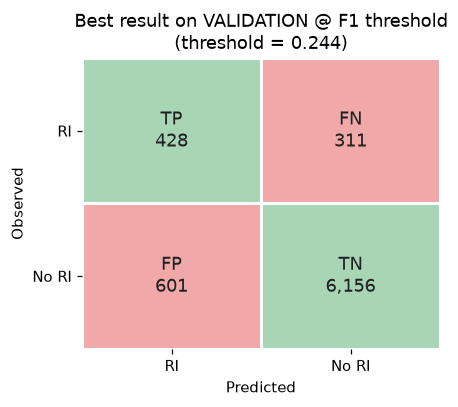


F2-optimal decision threshold = 0.125

Best result on VALIDATION @ F2 threshold | Threshold: 0.125
Confusion Matrix:
  TP: 578           FN: 161         
  FP: 1,384         TN: 5,373       
----------------------------------------------------------------------------------------------------
Performance Scores:
  Recall:    0.782      Precision: 0.295     
  F1 Score:  0.428      F2 Score:  0.588     
  CSI:       0.272      FAR:       0.705     



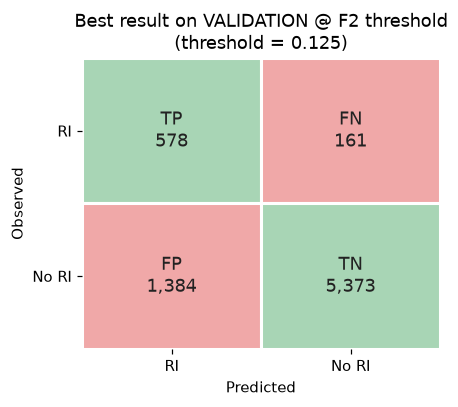

In [70]:
DECISION_THRESHOLD_F1_OPTIMIZED = best_threshold(y_val, val_probs, beta=1.0) # F1 used to find the best threshold
print(f"F1-optimal decision threshold = {DECISION_THRESHOLD_F1_OPTIMIZED:.3f}")

confusion(y_val, val_probs, DECISION_THRESHOLD_F1_OPTIMIZED, "Best result on VALIDATION @ F1 threshold");
plot_confusion(y_val, val_probs, DECISION_THRESHOLD_F1_OPTIMIZED, "Best result on VALIDATION @ F1 threshold");

print()

DECISION_THRESHOLD_F2_OPTIMIZED = best_threshold(y_val, val_probs, beta=2.0) # F2 used to find the best threshold
print(f"F2-optimal decision threshold = {DECISION_THRESHOLD_F2_OPTIMIZED:.3f}")

confusion(y_val, val_probs, DECISION_THRESHOLD_F2_OPTIMIZED, "Best result on VALIDATION @ F2 threshold");
plot_confusion(y_val, val_probs, DECISION_THRESHOLD_F2_OPTIMIZED, "Best result on VALIDATION @ F2 threshold");

---
>### 🧠 Pause and Think
>
>Look at 2 confusion matrices in the above cell produced at two different thresholds.
>
>Since we care more about **catching RI events**, we compare two thresholds:
>
>* **F1-optimized threshold:** balances precision and recall.
>* **F2-optimized threshold:** gives more importance to recall.
>
>Now compare the **confusion matrices and key metrics** at both thresholds. We would generally expect F2 to catch **more RI events (higher recall, fewer FN)**, but also give **more false alarms (higher FP, lower precision)**.
>
>Look at how **FAR, POFD, CSI, F1, F2** change as well. This helps us see the full trade-off, rather than focusing on recall alone.
>
>The important question is: **How many extra RI events do we catch with F2, and how many extra false alarms do we have to accept?** That trade-off will help us decide which threshold makes more sense for our RI prediction task.
>
>Moving foreward, we will be looking at all evaluation metrics based on **F2-optimized threshold** only because we care about higher recall.


### 🔄 Try It Yourself: Change the Decision Threshold

The model outputs a probability that a storm will undergo RI. Change the **decision threshold** below to see how it affects **precision, recall, F2, CSI, and FAR**. A lower threshold catches more RI events (higher recall) but also produces more false alarms (lower precision), while a higher threshold does the opposite.



Selecting custom threshold | Threshold: 0.000
Confusion Matrix:
  TP: 739           FN: 0           
  FP: 6,757         TN: 0           
----------------------------------------------------------------------------------------------------
Performance Scores:
  Recall:    1.000      Precision: 0.099     
  F1 Score:  0.179      F2 Score:  0.354     
  CSI:       0.099      FAR:       0.901     



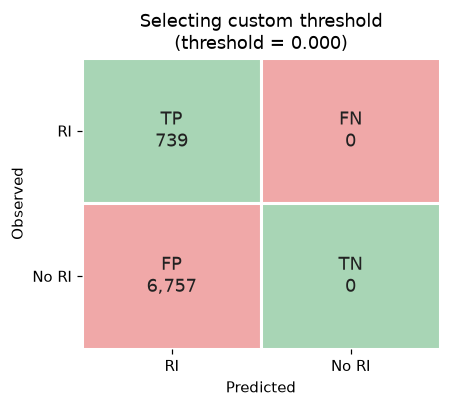

In [71]:
# Change the threshold value on the line below. It should be between 0 and 1, both inclusive.
your_threshold = 0
assert 0 <= your_threshold <= 1, "Threshold must be between 0 and 1."
confusion(y_val, val_probs, your_threshold, "Selecting custom threshold");
plot_confusion(y_val, val_probs, your_threshold, "Selecting custom threshold");

---
<a name="results-and-discussion"></a>

# Results & Discussion

The final results are evaluated on the **held-out test set**, using the model, calibration, and threshold selected earlier. We then examine the test predictions in more detail through **error analysis**, looking at where the model performs well, where it struggles, and which features contribute most to its predictions.


## 1. Held-Out Test Evaluation

We now apply the final model, calibration, and threshold to the test set. **The test set is used only once, at this stage**, to measure performance on unseen storms.

We report both **ranking metrics**, such as PR-AUC and ROC-AUC, and **threshold-based metrics**, such as recall, precision, F1, F2, and CSI. This gives us a fuller picture of how well the model identifies RI events and how useful its predictions are at the chosen threshold.

In [72]:
test_scores = best_model.predict_proba(X_test_best)[:, 1]
test_probs  = calibrator.predict(test_scores)

results = [
    evaluate("climatology", y_test,
             climatology_model.predict_proba(X_test_best)[:, 1]),
    evaluate("wind-trend rule", y_test,
             predict_proba_wind_trend(df_test, wind_threshold)[:, 1]),
    evaluate("logistic regression", y_test,
             logistic_model.predict_proba(X_test_best)[:, 1]),
    evaluate(f"{BEST_MODEL_NAME} (best)", y_test, test_probs),
]
print()
display(pd.DataFrame(results).round(4))

climatology                PR-AUC=0.1024  ROC-AUC=0.5000  BSS=+0.0000
wind-trend rule            PR-AUC=0.1566  ROC-AUC=0.6098  BSS=-0.6687
logistic regression        PR-AUC=0.3357  ROC-AUC=0.8306  BSS=-1.0688
xgboost (best)             PR-AUC=0.4200  ROC-AUC=0.8563  BSS=+0.2252



,model,pr_auc,roc_auc,bss
0,climatology,0.1024,0.5000,0.0000
1,wind-trend rule,0.1566,0.6098,-0.6687
2,logistic regression,0.3357,0.8306,-1.0688
3,xgboost (best),0.4200,0.8563,0.2252



Best model on TEST @ F2 threshold | Threshold: 0.125
Confusion Matrix:
  TP: 1,066         FN: 347         
  FP: 2,506         TN: 9,879       
----------------------------------------------------------------------------------------------------
Performance Scores:
  Recall:    0.754      Precision: 0.298     
  F1 Score:  0.428      F2 Score:  0.578     
  CSI:       0.272      FAR:       0.702     



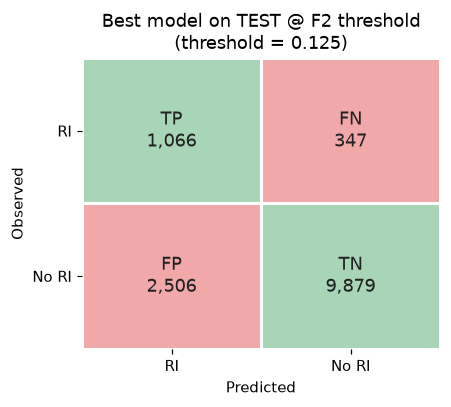

In [73]:
confusion(y_test, test_probs, DECISION_THRESHOLD_F2_OPTIMIZED,f"Best model on TEST @ F2 threshold");
plot_confusion(y_test, test_probs, DECISION_THRESHOLD_F2_OPTIMIZED, "Best model on TEST @ F2 threshold");

>### ℹ️  How to Read These Results
>
>The model was tuned for **F2** at a threshold of **0.125**, so we prioritize >**catching RI events** over keeping warnings clean.
>
>**In plain terms:** it catches about **3 out of 4 RI events** (Recall = 0.754), but only **3 out of 10 RI warnings are correct** (Precision = 0.298). This means more false alarms, but fewer missed RI events.
>
>| Metric    | Validation |  Test |
>| --------- | :--------: | :---: |
>| Recall    |    0.782   | 0.754 |
>| Precision |    0.295   | 0.298 |
>| F2        |    0.588   | 0.578 |
>| CSI       |    0.272   | 0.272 |
>| FAR       |    0.705   | 0.702 |
>
>The similar validation and test results suggest the **0.125 threshold generalizes reasonably well**.
>
>Precision of **0.298** is also meaningful: with an RI rate of about 10%, the model's warnings are correct roughly **3× more often than the base-rate expectation**.
>
>Finally, **accuracy is misleading here**: the model gets 79.3% accuracy, >while always predicting "No RI" gets 89.8%. Yet that baseline catches **zero RI events**.



---
## 2. Error Analysis

This section looks at **where and when the model makes mistakes** using the locked test predictions from Phase 5. We examine performance across different basins and time periods and use feature importance to better understand what the model is learning.

These analyses are **diagnostic only**: there is no refitting or changing of the model. Any findings are used to guide future improvements, not to change the test results already reported.


### 2.1 Per basin analysis

In [74]:
report_by_group(df_test, y_test, test_probs, "basin")

,storms,obs,RI,RI %,PR-AUC,vs base
basin,,,,,,
EP,198,"2,941",302,10.3%,0.466,4.5x
NA,165,"2,702",217,8.0%,0.369,4.6x
NI,54,713,74,10.4%,0.514,4.9x
SI,132,"2,539",250,9.8%,0.339,3.4x
SP,83,"1,291",129,10.0%,0.335,3.3x
WP,237,"3,612",441,12.2%,0.484,4.0x


---
### 2.2 Feature Importance

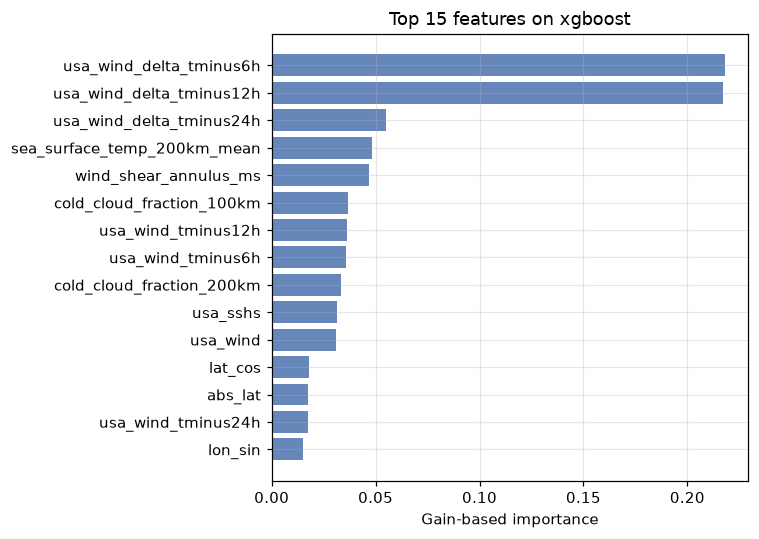

In [75]:
if hasattr(best_model, "feature_importances_"):
    importance = (pd.Series(best_model.feature_importances_,
                            index=BEST_FEATURES)
                    .sort_values(ascending=True)
                    .tail(15))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(importance.index, importance.values, color="#4C72B0", alpha=0.85)
    ax.set_xlabel("Gain-based importance")
    ax.set_title(f"Top 15 features on {BEST_MODEL_NAME}")
    plt.tight_layout()
    plt.show()

---
## Limitations

### 1. ERA5 is a reanalysis data, and is not available in real time

>Our model uses atmospheric variables from ERA5 reanalysis. These data are produced after observations have been collected and are therefore not available at the exact time a forecast would need to be made. As a result, this study does **not represent a fully operational real-time forecasting system**, but can definitely analyze what features contribute to RI, given they are available in the real-time.

### 2. RI is a relatively rare event

>Rapid intensification occurs in only a small fraction of the storm observations in our dataset. This class imbalance makes RI inherently very difficult to predict.

### 3. Storm behavior changes over time

>The frequency of RI is not constant across the dataset splits. In our experiments, the RI rate is higher in the validation and test periods than in the training period. This means that the relationship between the predictors and RI may change over time (potential reasons: satellite imagery and data collection methods improved drastically, RI incidents really increased in recent times due to warmer sea temperature).
>
>So performance on future storms may differ from performance on historical storms. This is an important limitation when applying the model to a changing climate.

### 4. The satellite-derived cloud feature is not perfectly uniform

> The cold-cloud fraction comes from GridSat-B1, which combines observations from multiple geostationary satellites. **Satellite coverage and data quality vary across different regions and years**, which can introduce some inconsistency in the cloud feature, particularly in areas with limited historical satellite coverage.
>
>In addition, the relatively coarse spatial resolution can miss some small-scale cloud structures near the cyclone center. These factors may introduce uncertainty into the satellite-based predictors.

### 5. Not chasing state-of-the-art

> This tutorial focuses on **interpretable, established RI predictors** and a **tabular modeling approach**, rather than pursuing state-of-the-art performance.
>
> More advanced deep-learning approaches, especially those that directly use satellite imagery or spatiotemporal data, may achieve better predictive performance. However, they also require **more data, computational resources, and modeling complexity**. The goal here is to build a **clear, reproducible, and easy-to-understand model** that highlights which environmental factors are useful for RI prediction.


---
## Next Steps

**Extend the Feature Set**

We only computed four ERA5 predictors and one GridSat-B1 cold cloud fraction. Adding variables like vorticity, relative humidity, or ocean heat content could meaningfully improve model skill.

**Try Different Models**

Experiment with XGBoost, LightGBM, or neural networks to better capture the rare nature of RI events beyond the baseline model.

**Better Ways to Address the Distribution Shift**

The RI rate increases over time in our dataset. Techniques like temporal reweighting or domain adaptation could help the model generalize to modern storm activity.

**Other Applications**

The same approach of combining IBTrACS track data, ERA5 reanalysis, and GridSat satellite imagery may be applied to TC track forecasting, rapid weakening detection, or multi-basin generalization.

<a name="references"></a>

# References


1. **National Hurricane Center.** *Hurricane Helene, 24–27 September 2024: Tropical Cyclone Report*. NOAA/NHC. [Link](https://www.nhc.noaa.gov/data/tcr/AL092024_Helene.pdf)

2. **DeMaria, M., & Kaplan, J.** (1994). *A Statistical Hurricane Intensity Prediction Scheme (SHIPS) for the Atlantic Basin*. Weather and Forecasting, 9(2), 209–220. [Link](https://doi.org/10.1175/1520-0434%281994%29009%3C0209:ASHIPS%3E2.0.CO;2)

3. **Kaplan, J., & DeMaria, M.** (2003). *Large-Scale Characteristics of Rapidly Intensifying Tropical Cyclones in the North Atlantic Basin*. Weather and Forecasting, 18(6), 1093–1108. [Link](https://doi.org/10.1175/1520-0434%282003%29018%3C1093:LCORIT%3E2.0.CO;2)

4. **Kaplan, J., DeMaria, M., & Knaff, J. A.** (2010). *A Revised Tropical Cyclone Rapid Intensification Index for the Atlantic and Eastern North Pacific Basins*. Weather and Forecasting, 25(1), 220–241. [Link](https://doi.org/10.1175/2009WAF2222280.1)

5. **Kaplan, J. et al.** (2015). *Evaluating Environmental Impacts on Tropical Cyclone Rapid Intensification Predictability Utilizing Statistical Models*. Weather and Forecasting, 30(5), 1374–1396. [Link](https://doi.org/10.1175/WAF-D-15-0032.1)

6. **Bhatia, K. et al.** (2022). *A potential explanation for the global increase in tropical cyclone rapid intensification*. Nature Communications. [Link](https://www.nature.com/articles/s41467-022-34321-6)

7. **Yi Li et al.** (2023). *Recent increases in tropical cyclone rapid intensification events in global offshore regions*. Nature Communications. [Link](https://www.nature.com/articles/s41467-023-40605-2)

8. **Knutson, T., NOAA.** *Global Warming and Hurricanes*. Summary of IPCC AR6 findings on tropical cyclone rapid intensification. [Link](https://www.gfdl.noaa.gov/global-warming-and-hurricanes/)

9. **NOAA Science Council.** *Hurricanes and Tropical Storms*. Economic value of forecast improvements under HFIP. [Link](https://sciencecouncil.noaa.gov/noaa-by-the-numbers/hurricane-literature-review-final/)


In [76]:
# @title Watermark
%load_ext watermark
%watermark -v -p fsspec,gcsfs,ipywidgets,matplotlib,numpy,pandas,plotly,requests,scikit-learn,xarray,xgboost,zarr -conda

Python implementation: CPython
Python version       : 3.13.15
IPython version      : 7.34.0

fsspec      : 2025.3.0
gcsfs       : 2025.3.0
ipywidgets  : 7.7.1
matplotlib  : 3.11.1
numpy       : 2.1.3
pandas      : 2.2.3
plotly      : 5.24.1
requests    : 2.32.4
scikit-learn: 1.9.0
xarray      : 2026.7.0
xgboost     : 3.4.1
zarr        : 3.3.0

